# Final Dataset Validation Audit

## Dataset readiness for regime-conditioned multivariate motif discovery in financial time series

# 1. Purpose of this notebook

This notebook validates the final dataset collection for the thesis:

**"Regime-Conditioned Multivariate Motif Discovery in Financial Time Series: A Reproducible Empirical Benchmark Under Nonstationarity"**

The goal is to confirm dataset coverage, file availability, row counts, timestamp continuity, missing values, duplicate timestamps, feature readiness, resampled frequency consistency, external validation data availability, and computational feasibility.

This notebook does **not** run Matrix Profile or LoCoMotif. It is only for dataset audit, quality validation, feature readiness, and exploratory data sanity checks.

# 2. Environment and path setup

This section defines the project paths used throughout the audit and creates the report output directory.

In [1]:
from pathlib import Path
import os
import json
from datetime import datetime, timezone
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyarrow as pa
from IPython.display import display

warnings.filterwarnings("default")
plt.style.use("default")
plt.rcParams.update({"figure.figsize": (10, 5), "axes.grid": True, "grid.alpha": 0.25, "font.size": 10})

PROJECT_ROOT = Path(r"C:\Users\learn\OneDrive\Desktop\Final Masters Thesis")
FINAL_DATASET_DIR = PROJECT_ROOT / "final_dataset"
RAW_DIR = FINAL_DATASET_DIR / "raw"
PROCESSED_DIR = FINAL_DATASET_DIR / "processed"
FEATURES_DIR = FINAL_DATASET_DIR / "features"
METADATA_DIR = FINAL_DATASET_DIR / "metadata"
OUTPUT_DIR = PROJECT_ROOT / "reports" / "dataset_validation"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for name, path in {
    "PROJECT_ROOT": PROJECT_ROOT,
    "FINAL_DATASET_DIR": FINAL_DATASET_DIR,
    "RAW_DIR": RAW_DIR,
    "PROCESSED_DIR": PROCESSED_DIR,
    "FEATURES_DIR": FEATURES_DIR,
    "METADATA_DIR": METADATA_DIR,
    "OUTPUT_DIR": OUTPUT_DIR,
}.items():
    print(f"{name}: {path}")

plot_paths = []
summary_tables = {}

def file_size_mb(path):
    path = Path(path)
    return round(path.stat().st_size / 1_000_000, 3) if path.exists() else np.nan

def folder_size_bytes(path):
    path = Path(path)
    return sum(p.stat().st_size for p in path.rglob("*") if p.is_file()) if path.exists() else 0

def save_current_plot(name):
    safe = "".join(ch if ch.isalnum() or ch in "_-" else "_" for ch in name)
    path = OUTPUT_DIR / f"{safe}.png"
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plot_paths.append(str(path))
    plt.show()
    print(f"Saved plot: {path}")
    return path

def safe_read_parquet(path, columns=None):
    path = Path(path)
    if not path.exists():
        warnings.warn(f"Missing parquet file: {path}")
        return None
    try:
        return pd.read_parquet(path, columns=columns)
    except Exception as exc:
        warnings.warn(f"Could not read {path}: {exc}")
        return None

def ensure_timestamp(frame):
    if frame is None or "timestamp" not in frame.columns:
        return frame
    frame = frame.copy()
    frame["timestamp"] = pd.to_datetime(frame["timestamp"], utc=True, errors="coerce")
    return frame.sort_values("timestamp").reset_index(drop=True)

def save_table(name, frame):
    if isinstance(frame, pd.DataFrame):
        path = OUTPUT_DIR / f"{name}.csv"
        frame.to_csv(path, index=False)
        summary_tables[name] = frame
        return path
    return None

PROJECT_ROOT: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis
FINAL_DATASET_DIR: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\final_dataset
RAW_DIR: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\final_dataset\raw
PROCESSED_DIR: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\final_dataset\processed
FEATURES_DIR: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\final_dataset\features
METADATA_DIR: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\final_dataset\metadata
OUTPUT_DIR: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\dataset_validation


# 3. Dataset folder overview

This section scans `final_dataset`, counts files by extension, counts Parquet files, and estimates storage by top-level folder. Crypto 1-minute and feature files should dominate storage.

Total files: 195
Parquet files: 182
Total final_dataset size: 2.072 GB


,extension,files
0,.parquet,182
1,.py,6
2,.csv,4
3,.md,2
4,.txt,1


,folder,files,parquet_files,size_mb,size_gb
0,raw,150,150,479.444,0.4794
1,processed,16,16,525.354,0.5254
2,features,16,16,1066.721,1.0667
3,metadata,6,0,0.265,0.0003
4,scripts,6,0,0.038,0.0000


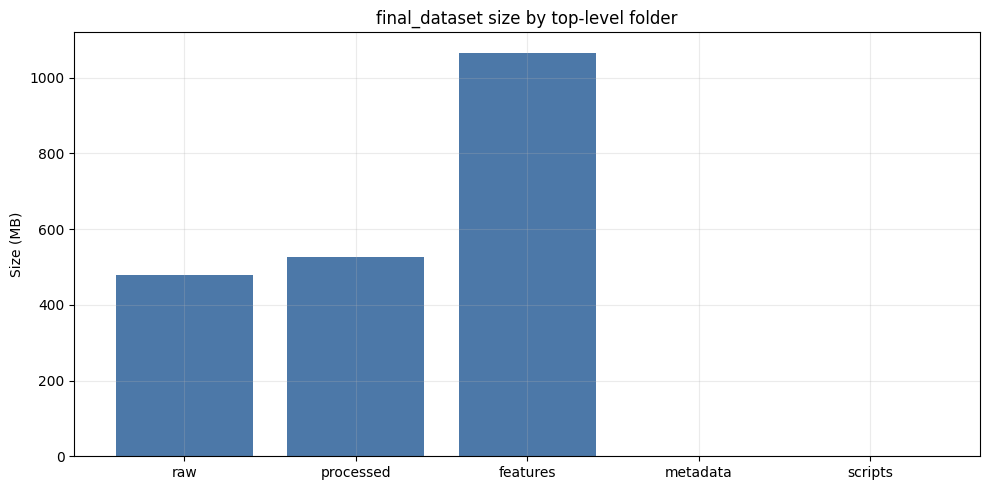

Saved plot: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\dataset_validation\folder_sizes_mb.png


WindowsPath('C:/Users/learn/OneDrive/Desktop/Final Masters Thesis/reports/dataset_validation/folder_sizes_mb.png')

In [2]:
all_files = [p for p in FINAL_DATASET_DIR.rglob("*") if p.is_file()]
parquet_count = sum(p.suffix.lower() == ".parquet" for p in all_files)
total_size_gb = folder_size_bytes(FINAL_DATASET_DIR) / 1_000_000_000
ext_counts = pd.Series([p.suffix.lower() or "[no extension]" for p in all_files]).value_counts().rename_axis("extension").reset_index(name="files")

rows = []
for folder in ["raw", "processed", "features", "metadata", "scripts"]:
    root = FINAL_DATASET_DIR / folder
    files = [p for p in root.rglob("*") if p.is_file()] if root.exists() else []
    size = folder_size_bytes(root)
    rows.append({"folder": folder, "files": len(files), "parquet_files": sum(p.suffix.lower() == ".parquet" for p in files), "size_mb": round(size / 1_000_000, 3), "size_gb": round(size / 1_000_000_000, 4)})
folder_overview_df = pd.DataFrame(rows)
save_table("folder_overview", folder_overview_df)

print(f"Total files: {len(all_files):,}")
print(f"Parquet files: {parquet_count:,}")
print(f"Total final_dataset size: {total_size_gb:.3f} GB")
display(ext_counts)
display(folder_overview_df)

plt.figure()
plt.bar(folder_overview_df["folder"], folder_overview_df["size_mb"], color="#4C78A8")
plt.ylabel("Size (MB)")
plt.title("final_dataset size by top-level folder")
save_current_plot("folder_sizes_mb")

# 4. Metadata inspection

The metadata files summarize the pipeline inventory, missing values, and download events. The download log may contain failed attempts from an earlier network-blocked run; the final validation status is more important than historical failed attempts.

In [3]:
metadata = {}
for name in ["dataset_inventory", "missing_data_report", "download_log"]:
    path = METADATA_DIR / f"{name}.csv"
    if path.exists():
        metadata[name] = pd.read_csv(path)
        print(f"{name}: shape={metadata[name].shape}, path={path}")
        display(metadata[name].head())
    else:
        warnings.warn(f"Missing metadata file: {path}")
        metadata[name] = pd.DataFrame()

inventory_df = metadata["dataset_inventory"]
missing_data_report_df = metadata["missing_data_report"]
download_log_df = metadata["download_log"]

inventory_status_counts = inventory_df["status"].value_counts(dropna=False).rename_axis("status").reset_index(name="count") if "status" in inventory_df else pd.DataFrame()
unresolved_failures_df = inventory_df[inventory_df["status"].astype(str).str.lower() != "ok"].copy() if "status" in inventory_df else pd.DataFrame()
failed_download_attempts_df = download_log_df[download_log_df["status"].isin(["error", "missing"])].copy() if "status" in download_log_df else pd.DataFrame()

print("Inventory status counts:")
display(inventory_status_counts)
print(f"Unresolved inventory failures: {len(unresolved_failures_df)}")
display(unresolved_failures_df.head(20))
print(f"Historical failed download attempts: {len(failed_download_attempts_df)}")
if "status" in download_log_df:
    display(download_log_df["status"].value_counts(dropna=False).rename_axis("status").reset_index(name="count"))
    display(failed_download_attempts_df.tail(20))

save_table("inventory_status_counts", inventory_status_counts)
save_table("unresolved_failures", unresolved_failures_df)

dataset_inventory: shape=(32, 15), path=C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\final_dataset\metadata\dataset_inventory.csv


,asset_class,symbol,frequency,kind,path,exists,rows,start_timestamp,end_timestamp,duplicate_timestamps,missing_timestamps,memory_size_mb,file_size_mb,columns,status
0,crypto,BTCUSDT,1m,processed,C:\Users\learn\OneDrive\Desktop\Final Masters ...,True,3154155,2020-01-01T00:00:00+00:00,2025-12-31T23:59:00+00:00,0,2325.0,280.720,210.017,timestamp|open|high|low|close|volume|close_tim...,ok
1,crypto,BTCUSDT,5m,processed,C:\Users\learn\OneDrive\Desktop\Final Masters ...,True,630834,2020-01-01T00:00:00+00:00,2025-12-31T23:55:00+00:00,0,462.0,56.144,44.054,timestamp|open|high|low|close|volume|quote_vol...,ok
2,crypto,BTCUSDT,15m,processed,C:\Users\learn\OneDrive\Desktop\Final Masters ...,True,210280,2020-01-01T00:00:00+00:00,2025-12-31T23:45:00+00:00,0,152.0,18.715,16.827,timestamp|open|high|low|close|volume|quote_vol...,ok
3,crypto,BTCUSDT,1h,processed,C:\Users\learn\OneDrive\Desktop\Final Masters ...,True,52577,2020-01-01T00:00:00+00:00,2025-12-31T23:00:00+00:00,0,31.0,4.679,4.779,timestamp|open|high|low|close|volume|quote_vol...,ok
4,crypto,BTCUSDT,1d,processed,C:\Users\learn\OneDrive\Desktop\Final Masters ...,True,2192,2020-01-01T00:00:00+00:00,2025-12-31T00:00:00+00:00,0,0.0,0.195,0.203,timestamp|open|high|low|close|volume|quote_vol...,ok


missing_data_report: shape=(430, 8), path=C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\final_dataset\metadata\missing_data_report.csv


,asset_class,symbol,frequency,kind,path,column,missing_values,missing_pct
0,crypto,BTCUSDT,1m,processed,C:\Users\learn\OneDrive\Desktop\Final Masters ...,timestamp,0,0.0
1,crypto,BTCUSDT,1m,processed,C:\Users\learn\OneDrive\Desktop\Final Masters ...,open,0,0.0
2,crypto,BTCUSDT,1m,processed,C:\Users\learn\OneDrive\Desktop\Final Masters ...,high,0,0.0
3,crypto,BTCUSDT,1m,processed,C:\Users\learn\OneDrive\Desktop\Final Masters ...,low,0,0.0
4,crypto,BTCUSDT,1m,processed,C:\Users\learn\OneDrive\Desktop\Final Masters ...,close,0,0.0


download_log: shape=(456, 11), path=C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\final_dataset\metadata\download_log.csv


...

,asset_class,symbol,frequency,kind,path,exists,rows,start_timestamp,end_timestamp,duplicate_timestamps,missing_timestamps,memory_size_mb,file_size_mb,columns,status


Historical failed download attempts: 152


,status,count
0,downloaded,174
1,error,152
2,skipped,126
3,processed,4


,timestamp_utc,script,asset_class,symbol,frequency,source,period,path,status,message,rows
132,2026-05-12T19:56:40.464831+00:00,01_download_crypto_binance.py,crypto,ETHUSDT,1m,Binance public data monthly spot klines,2024-12,NaN,error,HTTPSConnectionPool(host='data.binance.vision'...,NaN
133,2026-05-12T19:56:46.528466+00:00,01_download_crypto_binance.py,crypto,ETHUSDT,1m,Binance public data monthly spot klines,2025-01,NaN,error,HTTPSConnectionPool(host='data.binance.vision'...,NaN
134,2026-05-12T19:56:52.622855+00:00,01_download_crypto_binance.py,crypto,ETHUSDT,1m,Binance public data monthly spot klines,2025-02,NaN,error,HTTPSConnectionPool(host='data.binance.vision'...,NaN
135,2026-05-12T19:56:58.674625+00:00,01_download_crypto_binance.py,crypto,ETHUSDT,1m,Binance public data monthly spot klines,2025-03,NaN,error,HTTPSConnectionPool(host='data.binance.vision'...,NaN
136,2026-05-12T19:57:04.741422+00:00,01_download_crypto_binance.py,crypto,ETHUSDT,1m,Binance public data monthly spot klines,2025-04,NaN,error,HTTPSConnectionPool(host='data.binance.vision'...,NaN
137,2026-05-12T19:57:10.797214+00:00,01_download_crypto_binance.py,crypto,ETHUSDT,1m,Binance public data monthly spot klines,2025-05,NaN,error,HTTPSConnectionPool(host='data.binance.vision'...,NaN
138,2026-05-12T19:57:16.871132+00:00,01_download_crypto_binance.py,crypto,ETHUSDT,1m,Binance public data monthly spot klines,2025-06,NaN,error,HTTPSConnectionPool(host='data.binance.vision'...,NaN
139,2026-05-12T19:57:22.954436+00:00,01_download_crypto_binance.py,crypto,ETHUSDT,1m,Binance public data monthly spot klines,2025-07,NaN,error,HTTPSConnectionPool(host='data.binance.vision'...,NaN
140,2026-05-12T19:57:29.026073+00:00,01_download_crypto_binance.py,crypto,ETHUSDT,1m,Binance public data monthly spot klines,2025-08,NaN,error,HTTPSConnectionPool(host='data.binance.vision'...,NaN
141,2026-05-12T19:57:35.085105+00:00,01_download_crypto_binance.py,crypto,ETHUSDT,1m,Binance public data monthly spot klines,2025-09,NaN,error,HTTPSConnectionPool(host='data.binance.vision'...,NaN


WindowsPath('C:/Users/learn/OneDrive/Desktop/Final Masters Thesis/reports/dataset_validation/unresolved_failures.csv')

# 5. Required file checklist

This section checks the required processed and feature files in the locked dataset plan. Missing files here would directly affect downstream motif discovery, regime detection, or external validation.

Required files missing: 0


,category,file,exists,size_mb
0,processed,processed/crypto/1m/BTCUSDT_1m_2020_2025.parquet,True,210.017
1,processed,processed/crypto/1m/ETHUSDT_1m_2020_2025.parquet,True,187.443
2,processed,processed/crypto/5m/BTCUSDT_5m_2020_2025.parquet,True,44.054
3,processed,processed/crypto/15m/BTCUSDT_15m_2020_2025.par...,True,16.827
4,processed,processed/crypto/1h/BTCUSDT_1h_2020_2025.parquet,True,4.779
5,processed,processed/crypto/1d/BTCUSDT_1d_2020_2025.parquet,True,0.203
6,processed,processed/crypto/5m/ETHUSDT_5m_2020_2025.parquet,True,40.747
7,processed,processed/crypto/15m/ETHUSDT_15m_2020_2025.par...,True,15.589
8,processed,processed/crypto/1h/ETHUSDT_1h_2020_2025.parquet,True,4.516
9,processed,processed/crypto/1d/ETHUSDT_1d_2020_2025.parquet,True,0.198


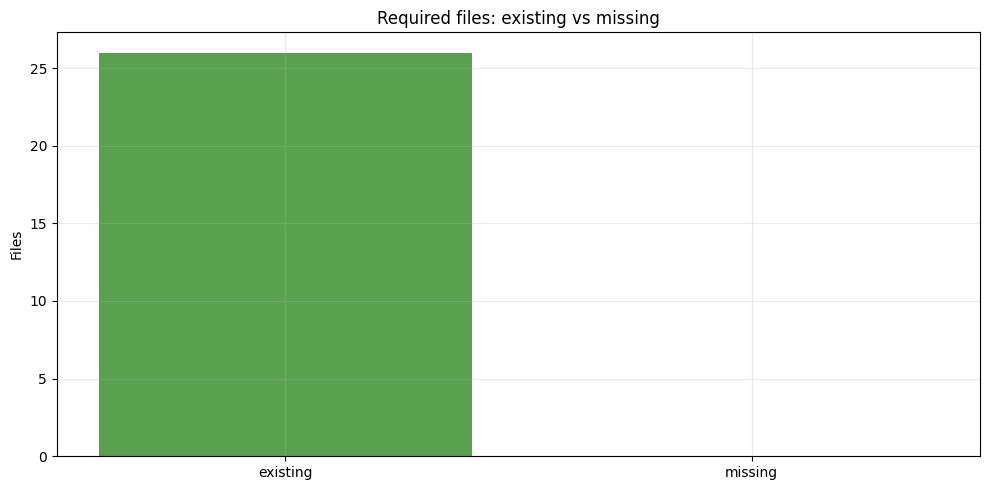

Saved plot: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\dataset_validation\required_files_existing_vs_missing.png


WindowsPath('C:/Users/learn/OneDrive/Desktop/Final Masters Thesis/reports/dataset_validation/required_files_existing_vs_missing.png')

In [4]:
required_processed = [
    "processed/crypto/1m/BTCUSDT_1m_2020_2025.parquet",
    "processed/crypto/1m/ETHUSDT_1m_2020_2025.parquet",
    "processed/crypto/5m/BTCUSDT_5m_2020_2025.parquet",
    "processed/crypto/15m/BTCUSDT_15m_2020_2025.parquet",
    "processed/crypto/1h/BTCUSDT_1h_2020_2025.parquet",
    "processed/crypto/1d/BTCUSDT_1d_2020_2025.parquet",
    "processed/crypto/5m/ETHUSDT_5m_2020_2025.parquet",
    "processed/crypto/15m/ETHUSDT_15m_2020_2025.parquet",
    "processed/crypto/1h/ETHUSDT_1h_2020_2025.parquet",
    "processed/crypto/1d/ETHUSDT_1d_2020_2025.parquet",
    "processed/fx/EURUSD_1d_2015_2025.parquet",
    "processed/fx/GBPUSD_1d_2015_2025.parquet",
    "processed/equity_indices/SP500_1d_2010_2025.parquet",
    "processed/equity_indices/NASDAQ100_1d_2010_2025.parquet",
    "processed/equity_indices/DAX_1d_2010_2025.parquet",
    "processed/volatility/VIX_1d_2010_2025.parquet",
]
required_features = [
    "features/crypto/BTCUSDT_1m_features_2020_2025.parquet",
    "features/crypto/ETHUSDT_1m_features_2020_2025.parquet",
    "features/crypto/BTCUSDT_5m_features_2020_2025.parquet",
    "features/crypto/ETHUSDT_5m_features_2020_2025.parquet",
    "features/crypto/BTCUSDT_15m_features_2020_2025.parquet",
    "features/crypto/ETHUSDT_15m_features_2020_2025.parquet",
    "features/crypto/BTCUSDT_1h_features_2020_2025.parquet",
    "features/crypto/ETHUSDT_1h_features_2020_2025.parquet",
    "features/crypto/BTCUSDT_1d_features_2020_2025.parquet",
    "features/crypto/ETHUSDT_1d_features_2020_2025.parquet",
]
required_file_checklist_df = pd.DataFrame(
    [{"category": "processed", "file": rel, "exists": (FINAL_DATASET_DIR / rel).exists(), "size_mb": file_size_mb(FINAL_DATASET_DIR / rel)} for rel in required_processed]
    + [{"category": "features", "file": rel, "exists": (FINAL_DATASET_DIR / rel).exists(), "size_mb": file_size_mb(FINAL_DATASET_DIR / rel)} for rel in required_features]
)
required_files_missing_count = int((~required_file_checklist_df["exists"]).sum())
print(f"Required files missing: {required_files_missing_count}")
display(required_file_checklist_df)
save_table("required_file_checklist", required_file_checklist_df)

counts = required_file_checklist_df["exists"].map({True: "existing", False: "missing"}).value_counts().reindex(["existing", "missing"], fill_value=0)
plt.figure()
plt.bar(counts.index, counts.values, color=["#59A14F", "#E15759"])
plt.ylabel("Files")
plt.title("Required files: existing vs missing")
save_current_plot("required_files_existing_vs_missing")

# 6. Core crypto 1-minute coverage audit

The expected period is **2020-01-01 00:00:00 UTC** to **2025-12-31 23:59:00 UTC** inclusive. This 6-calendar-year span should contain **3,156,480** complete 1-minute timestamps. A missing rate around **0.074%** is negligible for thesis-scale analysis if documented and handled consistently.

,asset,rows,expected_rows,missing_timestamps,missing_pct,duplicate_timestamps,start,end,min_timestamp_gap,median_timestamp_gap,max_timestamp_gap,memory_usage_mb,file_size_mb
0,BTCUSDT,3154155,3156480,2325,0.073658,0,2020-01-01 00:00:00+00:00,2025-12-31 23:59:00+00:00,0 days 00:01:00,0 days 00:01:00,0 days 05:55:00,280.72,210.017
1,ETHUSDT,3154154,3156480,2326,0.073690,0,2020-01-01 00:00:00+00:00,2025-12-31 23:59:00+00:00,0 days 00:01:00,0 days 00:01:00,0 days 05:55:00,280.72,187.443


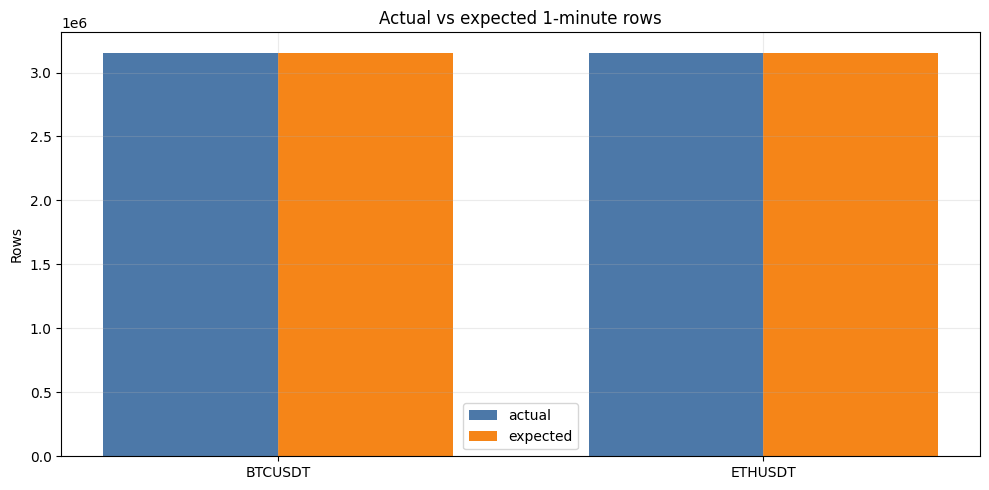

Saved plot: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\dataset_validation\crypto_1m_actual_vs_expected_rows.png


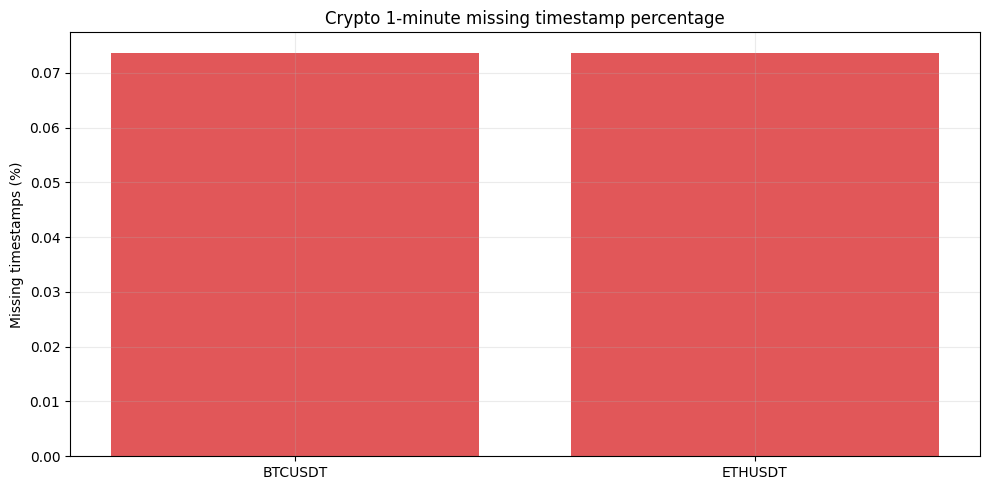

Saved plot: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\dataset_validation\crypto_1m_missing_timestamp_percentage.png


WindowsPath('C:/Users/learn/OneDrive/Desktop/Final Masters Thesis/reports/dataset_validation/crypto_1m_missing_timestamp_percentage.png')

In [5]:
crypto_1m_paths = {
    "BTCUSDT": PROCESSED_DIR / "crypto" / "1m" / "BTCUSDT_1m_2020_2025.parquet",
    "ETHUSDT": PROCESSED_DIR / "crypto" / "1m" / "ETHUSDT_1m_2020_2025.parquet",
}
expected_start = pd.Timestamp("2020-01-01 00:00:00", tz="UTC")
expected_end = pd.Timestamp("2025-12-31 23:59:00", tz="UTC")
expected_index_1m = pd.date_range(expected_start, expected_end, freq="1min")
expected_rows_1m = len(expected_index_1m)

crypto_1m = {}
coverage_rows = []
for asset, path in crypto_1m_paths.items():
    frame = ensure_timestamp(safe_read_parquet(path))
    if frame is None:
        continue
    crypto_1m[asset] = frame
    ts = frame["timestamp"].sort_values().drop_duplicates()
    missing = expected_index_1m.difference(pd.DatetimeIndex(ts))
    diffs = ts.diff().dropna()
    coverage_rows.append({
        "asset": asset,
        "rows": len(frame),
        "expected_rows": expected_rows_1m,
        "missing_timestamps": len(missing),
        "missing_pct": len(missing) / expected_rows_1m * 100,
        "duplicate_timestamps": int(frame["timestamp"].duplicated().sum()),
        "start": ts.min(),
        "end": ts.max(),
        "min_timestamp_gap": diffs.min() if len(diffs) else pd.NaT,
        "median_timestamp_gap": diffs.median() if len(diffs) else pd.NaT,
        "max_timestamp_gap": diffs.max() if len(diffs) else pd.NaT,
        "memory_usage_mb": round(frame.memory_usage(deep=True).sum() / 1_000_000, 3),
        "file_size_mb": file_size_mb(path),
    })
crypto_1m_coverage_df = pd.DataFrame(coverage_rows)
display(crypto_1m_coverage_df)
save_table("crypto_1m_coverage", crypto_1m_coverage_df)

x = np.arange(len(crypto_1m_coverage_df))
plt.figure()
plt.bar(x - 0.18, crypto_1m_coverage_df["rows"], 0.36, label="actual", color="#4C78A8")
plt.bar(x + 0.18, crypto_1m_coverage_df["expected_rows"], 0.36, label="expected", color="#F58518")
plt.xticks(x, crypto_1m_coverage_df["asset"])
plt.ylabel("Rows")
plt.title("Actual vs expected 1-minute rows")
plt.legend()
save_current_plot("crypto_1m_actual_vs_expected_rows")

plt.figure()
plt.bar(crypto_1m_coverage_df["asset"], crypto_1m_coverage_df["missing_pct"], color="#E15759")
plt.ylabel("Missing timestamps (%)")
plt.title("Crypto 1-minute missing timestamp percentage")
save_current_plot("crypto_1m_missing_timestamp_percentage")

# 7. Timestamp gap visualization

Timestamp gaps matter for Matrix Profile and LoCoMotif because motif windows assume ordered, regularly spaced observations. Small gaps can be handled by resampling, interpolation, or dropping affected windows.

BTCUSDT: gaps > 1 minute = 15


,asset,gap_start,gap_end,gap_minutes,missing_minutes_inside_gap,year
1,BTCUSDT,2020-02-19 11:35:00,2020-02-19 17:30:00,355,354,2020
11,BTCUSDT,2021-04-25 04:00:00,2021-04-25 08:45:00,285,284,2021
12,BTCUSDT,2021-08-13 01:59:00,2021-08-13 06:30:00,271,270,2021
6,BTCUSDT,2020-12-21 14:09:00,2020-12-21 18:00:00,231,230,2020
4,BTCUSDT,2020-06-28 01:59:00,2020-06-28 05:30:00,211,210,2020
3,BTCUSDT,2020-04-25 01:59:00,2020-04-25 04:30:00,151,150,2020
10,BTCUSDT,2021-04-20 01:59:00,2021-04-20 04:30:00,151,150,2021
2,BTCUSDT,2020-03-04 09:21:00,2020-03-04 11:30:00,129,128,2020
13,BTCUSDT,2021-09-29 06:59:00,2021-09-29 09:00:00,121,120,2021
9,BTCUSDT,2021-03-06 01:59:00,2021-03-06 03:30:00,91,90,2021


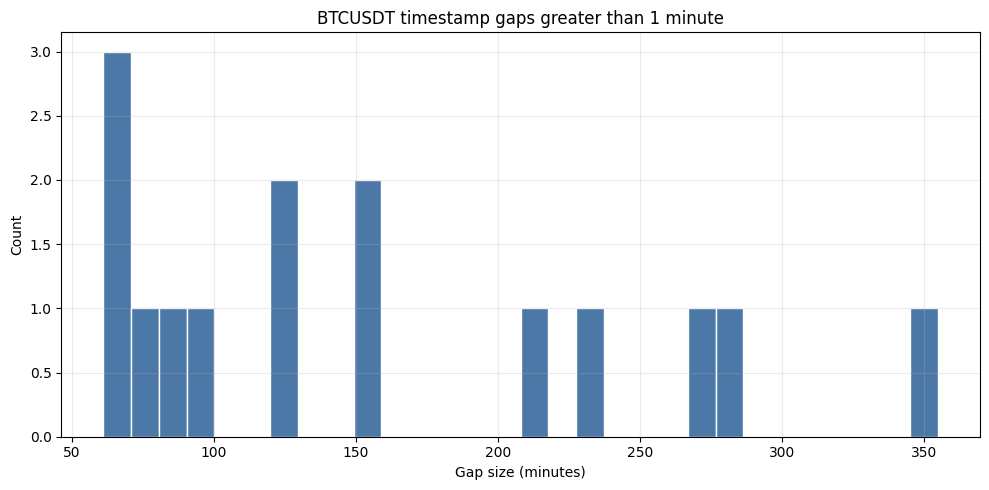

Saved plot: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\dataset_validation\BTCUSDT_gap_size_histogram.png


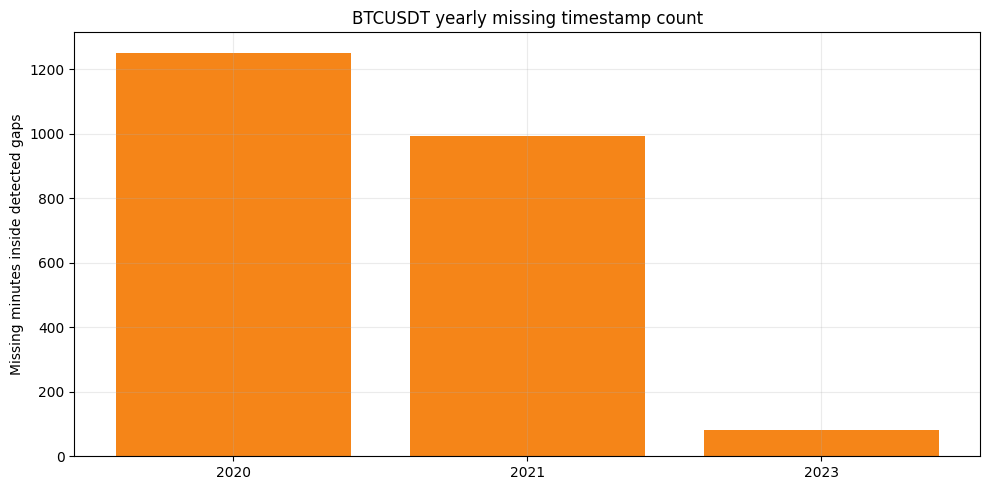

Saved plot: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\dataset_validation\BTCUSDT_yearly_missing_timestamps.png
ETHUSDT: gaps > 1 minute = 15


,asset,gap_start,gap_end,gap_minutes,missing_minutes_inside_gap,year
1,ETHUSDT,2020-02-19 11:35:00,2020-02-19 17:30:00,355,354,2020
11,ETHUSDT,2021-04-25 04:00:00,2021-04-25 08:45:00,285,284,2021
12,ETHUSDT,2021-08-13 01:59:00,2021-08-13 06:30:00,271,270,2021
6,ETHUSDT,2020-12-21 14:08:00,2020-12-21 18:00:00,232,231,2020
4,ETHUSDT,2020-06-28 01:59:00,2020-06-28 05:30:00,211,210,2020
3,ETHUSDT,2020-04-25 01:59:00,2020-04-25 04:30:00,151,150,2020
10,ETHUSDT,2021-04-20 01:59:00,2021-04-20 04:30:00,151,150,2021
2,ETHUSDT,2020-03-04 09:21:00,2020-03-04 11:30:00,129,128,2020
13,ETHUSDT,2021-09-29 06:59:00,2021-09-29 09:00:00,121,120,2021
9,ETHUSDT,2021-03-06 01:59:00,2021-03-06 03:30:00,91,90,2021


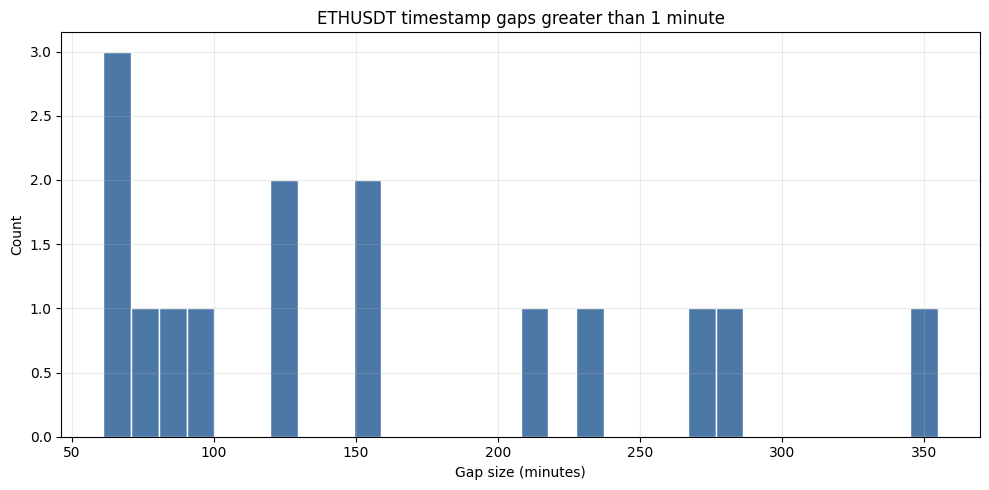

Saved plot: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\dataset_validation\ETHUSDT_gap_size_histogram.png


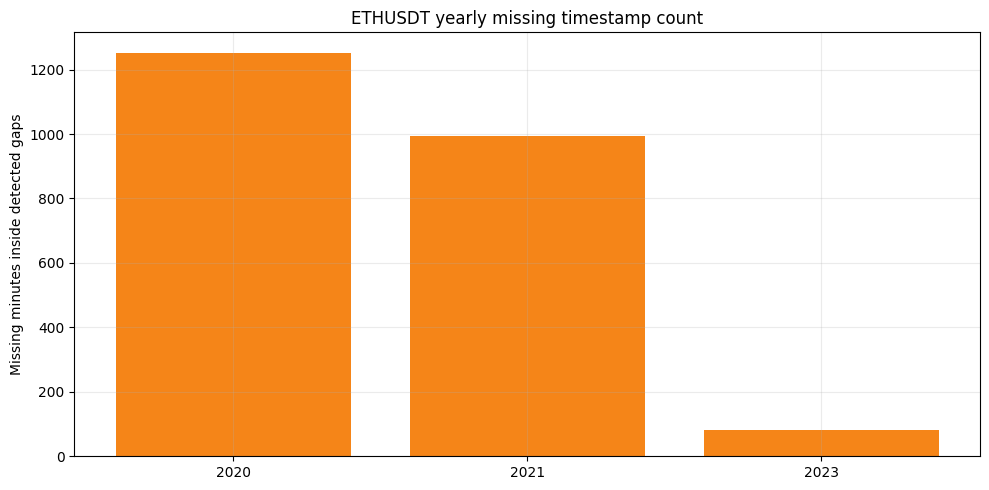

Saved plot: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\dataset_validation\ETHUSDT_yearly_missing_timestamps.png


WindowsPath('C:/Users/learn/OneDrive/Desktop/Final Masters Thesis/reports/dataset_validation/ETHUSDT_1m_gap_report.csv')

In [6]:
gap_reports = {}
yearly_gap_rows = []
for asset, frame in crypto_1m.items():
    ts = frame["timestamp"].sort_values().drop_duplicates().reset_index(drop=True)
    diffs = ts.diff()
    mask = diffs > pd.Timedelta(minutes=1)
    gaps = pd.DataFrame({
        "asset": asset,
        "gap_start": ts.shift(1)[mask].values,
        "gap_end": ts[mask].values,
        "gap_minutes": (diffs[mask] / pd.Timedelta(minutes=1)).astype(int).values,
    })
    if not gaps.empty:
        gaps["missing_minutes_inside_gap"] = gaps["gap_minutes"] - 1
        gaps["year"] = pd.to_datetime(gaps["gap_start"], utc=True).dt.year
    else:
        gaps["missing_minutes_inside_gap"] = pd.Series(dtype="int64")
        gaps["year"] = pd.Series(dtype="int64")
    gap_reports[asset] = gaps
    gaps.to_csv(OUTPUT_DIR / f"{asset}_1m_gap_report.csv", index=False)
    print(f"{asset}: gaps > 1 minute = {len(gaps)}")
    display(gaps.sort_values("gap_minutes", ascending=False).head(20))

    if not gaps.empty:
        plt.figure()
        plt.hist(gaps["gap_minutes"], bins=30, color="#4C78A8", edgecolor="white")
        plt.xlabel("Gap size (minutes)")
        plt.ylabel("Count")
        plt.title(f"{asset} timestamp gaps greater than 1 minute")
        save_current_plot(f"{asset}_gap_size_histogram")

        yearly = gaps.groupby("year", as_index=False)["missing_minutes_inside_gap"].sum()
        yearly["asset"] = asset
        yearly_gap_rows.append(yearly)
        plt.figure()
        plt.bar(yearly["year"].astype(str), yearly["missing_minutes_inside_gap"], color="#F58518")
        plt.ylabel("Missing minutes inside detected gaps")
        plt.title(f"{asset} yearly missing timestamp count")
        save_current_plot(f"{asset}_yearly_missing_timestamps")

yearly_gap_df = pd.concat(yearly_gap_rows, ignore_index=True) if yearly_gap_rows else pd.DataFrame()
save_table("yearly_gap_counts", yearly_gap_df)
save_table("BTCUSDT_1m_gap_report", gap_reports.get("BTCUSDT", pd.DataFrame()))
save_table("ETHUSDT_1m_gap_report", gap_reports.get("ETHUSDT", pd.DataFrame()))

# 8. OHLCV sanity checks

These checks validate basic market data consistency before motif discovery: prices should be positive, volumes and trade counts should be non-negative, and OHLC relationships should hold.

,asset,check_name,violations,violation_pct
0,BTCUSDT,open_positive,0,0.0
1,BTCUSDT,high_positive,0,0.0
2,BTCUSDT,low_positive,0,0.0
3,BTCUSDT,close_positive,0,0.0
4,BTCUSDT,volume_non_negative,0,0.0
5,BTCUSDT,high_ge_low,0,0.0
6,BTCUSDT,high_ge_open,0,0.0
7,BTCUSDT,high_ge_close,0,0.0
8,BTCUSDT,low_le_open,0,0.0
9,BTCUSDT,low_le_close,0,0.0


""


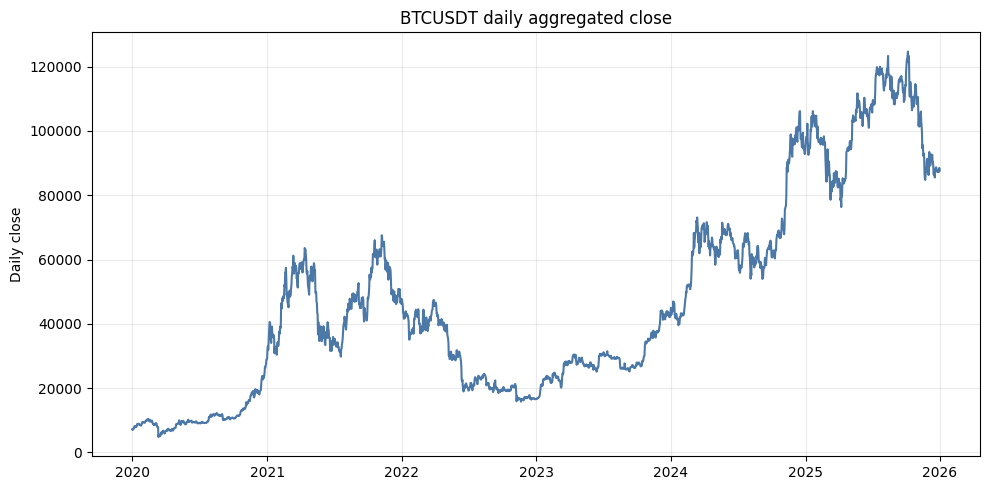

Saved plot: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\dataset_validation\BTCUSDT_daily_close.png


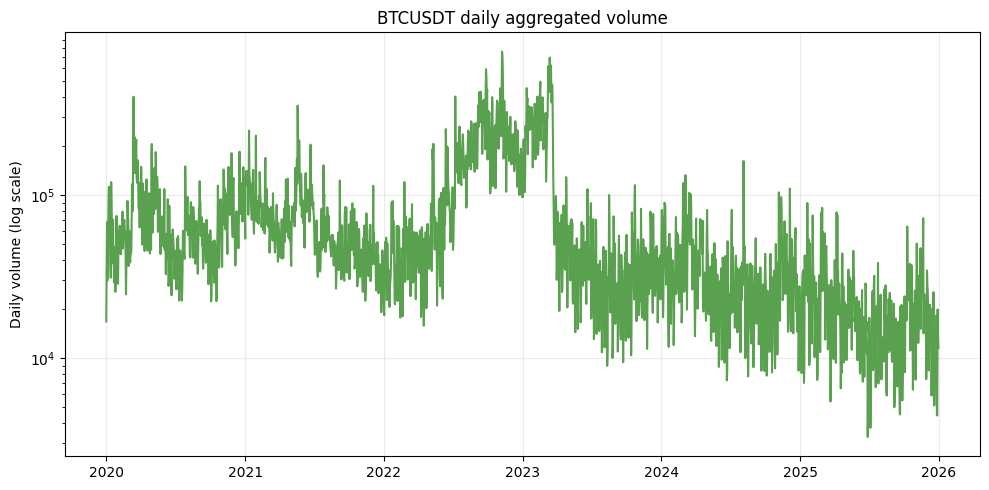

Saved plot: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\dataset_validation\BTCUSDT_daily_volume_log.png


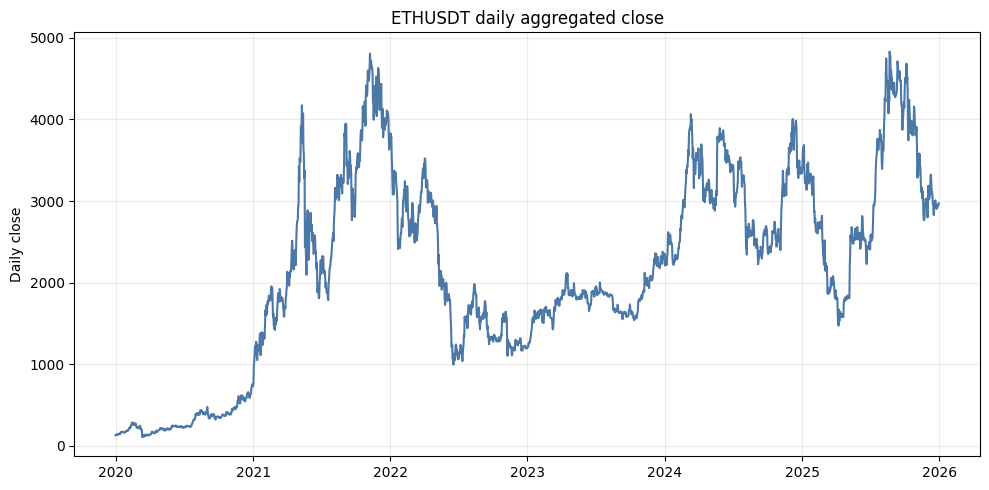

Saved plot: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\dataset_validation\ETHUSDT_daily_close.png


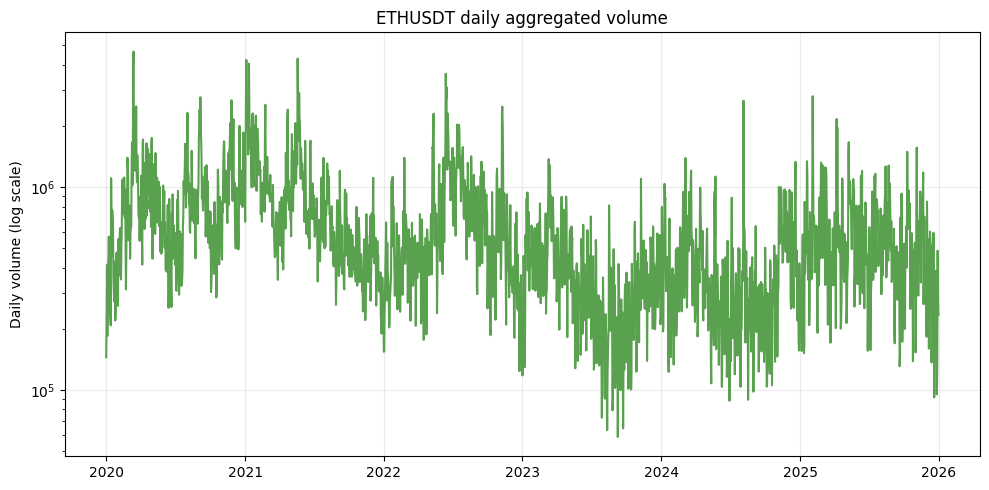

Saved plot: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\dataset_validation\ETHUSDT_daily_volume_log.png


In [7]:
check_rows, violation_samples = [], []
for asset, frame in crypto_1m.items():
    checks = {
        "open_positive": frame["open"] > 0,
        "high_positive": frame["high"] > 0,
        "low_positive": frame["low"] > 0,
        "close_positive": frame["close"] > 0,
        "volume_non_negative": frame["volume"] >= 0,
        "high_ge_low": frame["high"] >= frame["low"],
        "high_ge_open": frame["high"] >= frame["open"],
        "high_ge_close": frame["high"] >= frame["close"],
        "low_le_open": frame["low"] <= frame["open"],
        "low_le_close": frame["low"] <= frame["close"],
    }
    if "number_of_trades" in frame.columns:
        checks["number_of_trades_non_negative"] = frame["number_of_trades"] >= 0
    for name, passed in checks.items():
        bad = ~passed.fillna(False)
        violations = int(bad.sum())
        check_rows.append({"asset": asset, "check_name": name, "violations": violations, "violation_pct": violations / len(frame) * 100})
        if violations:
            sample = frame.loc[bad].head(5).copy()
            sample.insert(0, "check_name", name)
            sample.insert(0, "asset", asset)
            violation_samples.append(sample)
ohlcv_sanity_df = pd.DataFrame(check_rows)
violating_rows_sample_df = pd.concat(violation_samples, ignore_index=True) if violation_samples else pd.DataFrame()
display(ohlcv_sanity_df)
display(violating_rows_sample_df.head(30))
save_table("ohlcv_sanity_checks", ohlcv_sanity_df)
save_table("ohlcv_violating_rows_sample", violating_rows_sample_df)

for asset, frame in crypto_1m.items():
    daily = frame.set_index("timestamp").resample("1D").agg({"close": "last", "volume": "sum"}).dropna(subset=["close"])
    plt.figure()
    plt.plot(daily.index, daily["close"], color="#4C78A8")
    plt.ylabel("Daily close")
    plt.title(f"{asset} daily aggregated close")
    save_current_plot(f"{asset}_daily_close")

    plt.figure()
    plt.plot(daily.index, daily["volume"], color="#59A14F")
    plt.yscale("log")
    plt.ylabel("Daily volume (log scale)")
    plt.title(f"{asset} daily aggregated volume")
    save_current_plot(f"{asset}_daily_volume_log")

# 9. Resampled frequency consistency

Resampled files support frequency sensitivity and reduce computation for HMM and LoCoMotif. Row counts should be approximately proportional to the 1-minute source frequency.

,asset,frequency,rows,start,end,duplicate_timestamps,missing_values_total,file_size_mb
0,BTCUSDT,1m,3154155,2020-01-01 00:00:00+00:00,2025-12-31 23:59:00+00:00,0,0,210.017
1,BTCUSDT,5m,630834,2020-01-01 00:00:00+00:00,2025-12-31 23:55:00+00:00,0,0,44.054
2,BTCUSDT,15m,210280,2020-01-01 00:00:00+00:00,2025-12-31 23:45:00+00:00,0,0,16.827
3,BTCUSDT,1h,52577,2020-01-01 00:00:00+00:00,2025-12-31 23:00:00+00:00,0,0,4.779
4,BTCUSDT,1d,2192,2020-01-01 00:00:00+00:00,2025-12-31 00:00:00+00:00,0,0,0.203
5,ETHUSDT,1m,3154154,2020-01-01 00:00:00+00:00,2025-12-31 23:59:00+00:00,0,0,187.443
6,ETHUSDT,5m,630834,2020-01-01 00:00:00+00:00,2025-12-31 23:55:00+00:00,0,0,40.747
7,ETHUSDT,15m,210280,2020-01-01 00:00:00+00:00,2025-12-31 23:45:00+00:00,0,0,15.589
8,ETHUSDT,1h,52577,2020-01-01 00:00:00+00:00,2025-12-31 23:00:00+00:00,0,0,4.516
9,ETHUSDT,1d,2192,2020-01-01 00:00:00+00:00,2025-12-31 00:00:00+00:00,0,0,0.198


,asset,frequency,actual_rows,expected_from_1m_ratio,ratio_error_pct
0,BTCUSDT,5m,630834,630831.000000,0.000476
1,BTCUSDT,15m,210280,210277.000000,0.001427
2,BTCUSDT,1h,52577,52569.250000,0.014742
3,BTCUSDT,1d,2192,2190.385417,0.073712
4,ETHUSDT,5m,630834,630830.800000,0.000507
5,ETHUSDT,15m,210280,210276.933333,0.001458
6,ETHUSDT,1h,52577,52569.233333,0.014774
7,ETHUSDT,1d,2192,2190.384722,0.073744


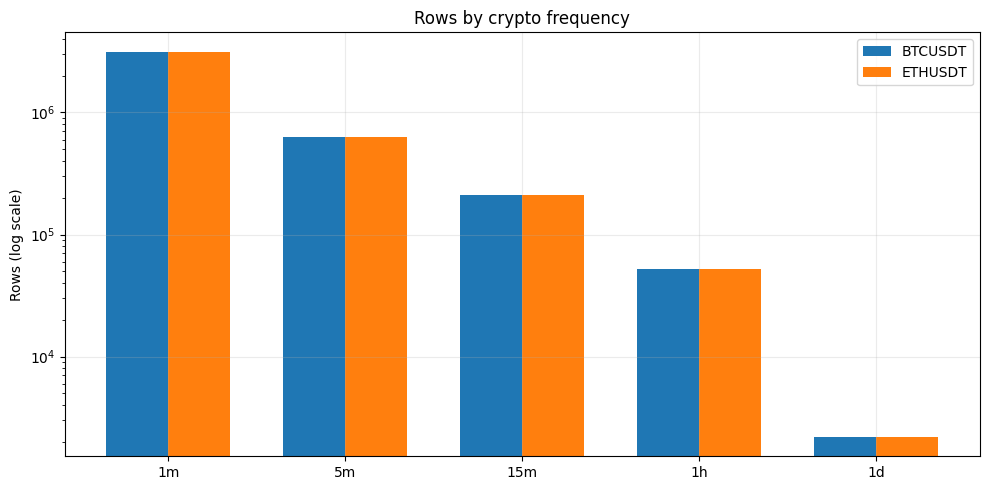

Saved plot: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\dataset_validation\crypto_rows_by_frequency.png


WindowsPath('C:/Users/learn/OneDrive/Desktop/Final Masters Thesis/reports/dataset_validation/crypto_rows_by_frequency.png')

In [8]:
freqs = ["1m", "5m", "15m", "1h", "1d"]
denom = {"5m": 5, "15m": 15, "1h": 60, "1d": 1440}
rows = []
for asset in ["BTCUSDT", "ETHUSDT"]:
    for freq in freqs:
        path = PROCESSED_DIR / "crypto" / freq / f"{asset}_{freq}_2020_2025.parquet"
        frame = ensure_timestamp(safe_read_parquet(path))
        if frame is None:
            continue
        core = [c for c in ["open", "high", "low", "close", "volume"] if c in frame.columns]
        rows.append({"asset": asset, "frequency": freq, "rows": len(frame), "start": frame["timestamp"].min(), "end": frame["timestamp"].max(), "duplicate_timestamps": int(frame["timestamp"].duplicated().sum()), "missing_values_total": int(frame[core].isna().sum().sum()), "file_size_mb": file_size_mb(path)})
resampled_consistency_df = pd.DataFrame(rows)
display(resampled_consistency_df)
save_table("resampled_frequency_consistency", resampled_consistency_df)

ratio_rows = []
for asset in ["BTCUSDT", "ETHUSDT"]:
    one = int(resampled_consistency_df.query("asset == @asset and frequency == '1m'")["rows"].iloc[0])
    for freq, d in denom.items():
        actual = int(resampled_consistency_df.query("asset == @asset and frequency == @freq")["rows"].iloc[0])
        expected = one / d
        ratio_rows.append({"asset": asset, "frequency": freq, "actual_rows": actual, "expected_from_1m_ratio": expected, "ratio_error_pct": (actual - expected) / expected * 100})
ratio_check_df = pd.DataFrame(ratio_rows)
display(ratio_check_df)
save_table("resampled_ratio_check", ratio_check_df)

pivot = resampled_consistency_df.pivot(index="frequency", columns="asset", values="rows").reindex(freqs)
plt.figure()
x = np.arange(len(pivot.index))
for i, asset in enumerate(pivot.columns):
    plt.bar(x + (i - 0.5) * 0.35, pivot[asset], 0.35, label=asset)
plt.xticks(x, pivot.index)
plt.yscale("log")
plt.ylabel("Rows (log scale)")
plt.title("Rows by crypto frequency")
plt.legend()
save_current_plot("crypto_rows_by_frequency")

# 10. Feature readiness audit

This section checks engineered feature files and verifies that required columns are present for volatility-quantile regimes, HMM regimes, Matrix Profile input construction, and LoCoMotif input construction.

Missing required feature columns: 3


,dataset,asset,frequency,file,rows,n_columns,missing_values_total,missing_pct,duplicate_timestamps,start,end,file_size_mb
0,crypto,BTCUSDT,15m,features/crypto/BTCUSDT_15m_features_2020_2025...,210280,19,111,0.002778,0,2020-01-01 00:00:00+00:00,2025-12-31 23:45:00+00:00,32.460
1,crypto,BTCUSDT,1d,features/crypto/BTCUSDT_1d_features_2020_2025....,2192,19,98,0.235305,0,2020-01-01 00:00:00+00:00,2025-12-31 00:00:00+00:00,0.374
2,crypto,BTCUSDT,1h,features/crypto/BTCUSDT_1h_features_2020_2025....,52577,19,125,0.012513,0,2020-01-01 00:00:00+00:00,2025-12-31 23:00:00+00:00,8.972
3,crypto,BTCUSDT,1m,features/crypto/BTCUSDT_1m_features_2020_2025....,3154155,19,380,0.000634,0,2020-01-01 00:00:00+00:00,2025-12-31 23:59:00+00:00,417.744
4,crypto,BTCUSDT,5m,features/crypto/BTCUSDT_5m_features_2020_2025....,630834,19,149,0.001243,0,2020-01-01 00:00:00+00:00,2025-12-31 23:55:00+00:00,86.613
5,crypto,ETHUSDT,15m,features/crypto/ETHUSDT_15m_features_2020_2025...,210280,19,111,0.002778,0,2020-01-01 00:00:00+00:00,2025-12-31 23:45:00+00:00,31.211
6,crypto,ETHUSDT,1d,features/crypto/ETHUSDT_1d_features_2020_2025....,2192,19,98,0.235305,0,2020-01-01 00:00:00+00:00,2025-12-31 00:00:00+00:00,0.369
7,crypto,ETHUSDT,1h,features/crypto/ETHUSDT_1h_features_2020_2025....,52577,19,125,0.012513,0,2020-01-01 00:00:00+00:00,2025-12-31 23:00:00+00:00,8.706
8,crypto,ETHUSDT,1m,features/crypto/ETHUSDT_1m_features_2020_2025....,3154154,19,380,0.000634,0,2020-01-01 00:00:00+00:00,2025-12-31 23:59:00+00:00,394.527
9,crypto,ETHUSDT,5m,features/crypto/ETHUSDT_5m_features_2020_2025....,630834,19,149,0.001243,0,2020-01-01 00:00:00+00:00,2025-12-31 23:55:00+00:00,83.228


,file,required_feature,exists
0,features/crypto/BTCUSDT_15m_features_2020_2025...,log_return,True
1,features/crypto/BTCUSDT_15m_features_2020_2025...,abs_log_return,True
2,features/crypto/BTCUSDT_15m_features_2020_2025...,pct_return,True
3,features/crypto/BTCUSDT_15m_features_2020_2025...,hl_range,True
4,features/crypto/BTCUSDT_15m_features_2020_2025...,rolling_volatility_30,True
...,...,...,...
104,features/fx/GBPUSD_1d_features_2015_2025.parquet,rolling_volatility_60,True
105,features/volatility/VIX_1d_features_2010_2025....,vix_level,True
106,features/volatility/VIX_1d_features_2010_2025....,vix_change,True
107,features/volatility/VIX_1d_features_2010_2025....,vix_percentile_252d,True


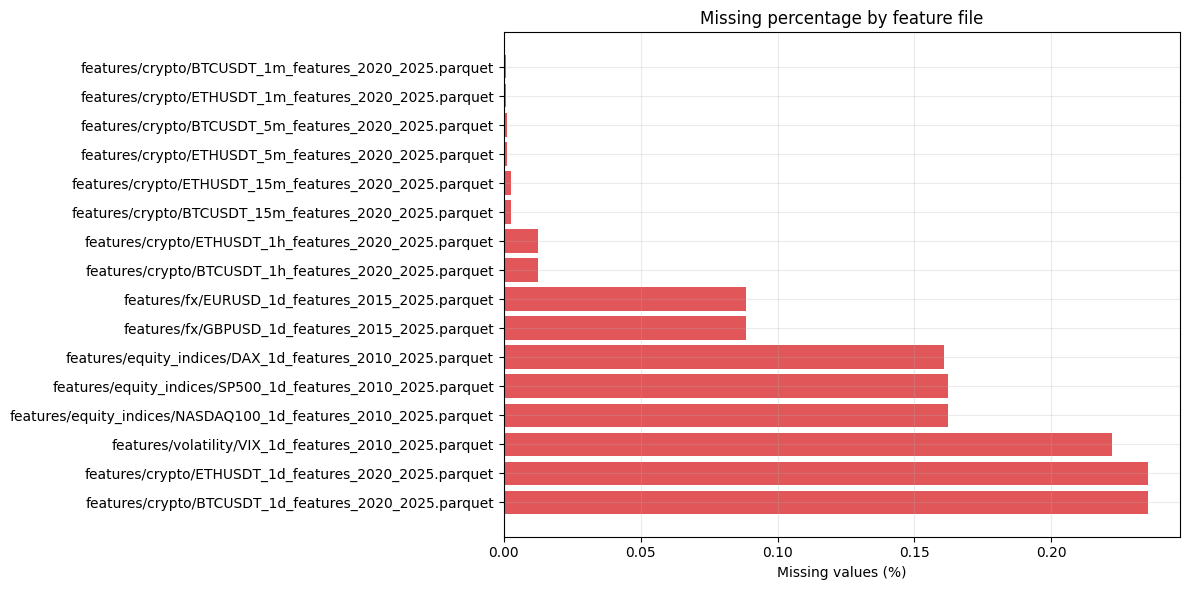

Saved plot: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\dataset_validation\feature_file_missing_percentage.png


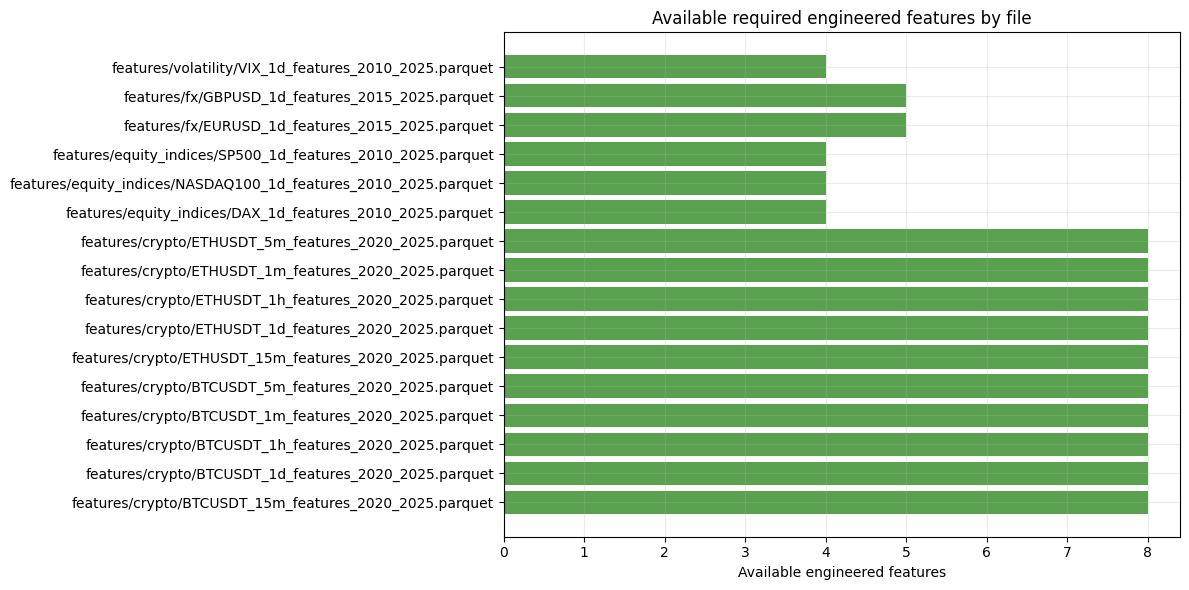

Saved plot: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\dataset_validation\engineered_feature_availability.png


WindowsPath('C:/Users/learn/OneDrive/Desktop/Final Masters Thesis/reports/dataset_validation/engineered_feature_availability.png')

In [9]:
feature_paths = sorted(FEATURES_DIR.rglob("*.parquet"))
required_crypto_features = ["log_return", "abs_log_return", "pct_return", "hl_range", "rolling_volatility_30", "rolling_volatility_60", "rolling_volatility_240", "volume_zscore"]
required_market_features = ["log_return", "abs_log_return", "pct_return", "rolling_volatility_20", "rolling_volatility_60"]
required_vix_features = ["vix_level", "vix_change", "vix_percentile_252d", "high_vix_flag"]
feature_summary_rows, feature_column_rows = [], []

for path in feature_paths:
    frame = ensure_timestamp(safe_read_parquet(path))
    if frame is None:
        continue
    rel = path.relative_to(FINAL_DATASET_DIR).as_posix()
    dataset = path.parent.name
    parts = path.stem.split("_")
    asset = parts[0]
    frequency = next((p for p in parts if p in {"1m", "5m", "15m", "1h", "1d"}), "unknown")
    missing_total = int(frame.isna().sum().sum())
    missing_pct = missing_total / (frame.shape[0] * frame.shape[1]) * 100
    feature_summary_rows.append({"dataset": dataset, "asset": asset, "frequency": frequency, "file": rel, "rows": len(frame), "n_columns": frame.shape[1], "missing_values_total": missing_total, "missing_pct": missing_pct, "duplicate_timestamps": int(frame["timestamp"].duplicated().sum()), "start": frame["timestamp"].min(), "end": frame["timestamp"].max(), "file_size_mb": file_size_mb(path)})
    required = required_crypto_features if dataset == "crypto" else required_vix_features if dataset == "volatility" else required_market_features
    for feature in required:
        feature_column_rows.append({"file": rel, "required_feature": feature, "exists": feature in frame.columns})

feature_readiness_df = pd.DataFrame(feature_summary_rows)
feature_column_check_df = pd.DataFrame(feature_column_rows)
missing_required_features_count = int((~feature_column_check_df["exists"]).sum()) if not feature_column_check_df.empty else 0
print(f"Missing required feature columns: {missing_required_features_count}")
display(feature_readiness_df.sort_values(["dataset", "asset", "frequency"]))
display(feature_column_check_df)
save_table("feature_readiness", feature_readiness_df)
save_table("feature_column_check", feature_column_check_df)

plt.figure(figsize=(12, 6))
plot_df = feature_readiness_df.sort_values("missing_pct", ascending=False)
plt.barh(plot_df["file"], plot_df["missing_pct"], color="#E15759")
plt.xlabel("Missing values (%)")
plt.title("Missing percentage by feature file")
save_current_plot("feature_file_missing_percentage")

counts = feature_column_check_df.groupby("file")["exists"].sum().reset_index(name="available_required_features")
plt.figure(figsize=(12, 6))
plt.barh(counts["file"], counts["available_required_features"], color="#59A14F")
plt.xlabel("Available engineered features")
plt.title("Available required engineered features by file")
save_current_plot("engineered_feature_availability")

# 11. Feature distribution sanity checks

This section inspects BTCUSDT and ETHUSDT 1-hour feature distributions. HMM should use engineered features and not raw close prices only.

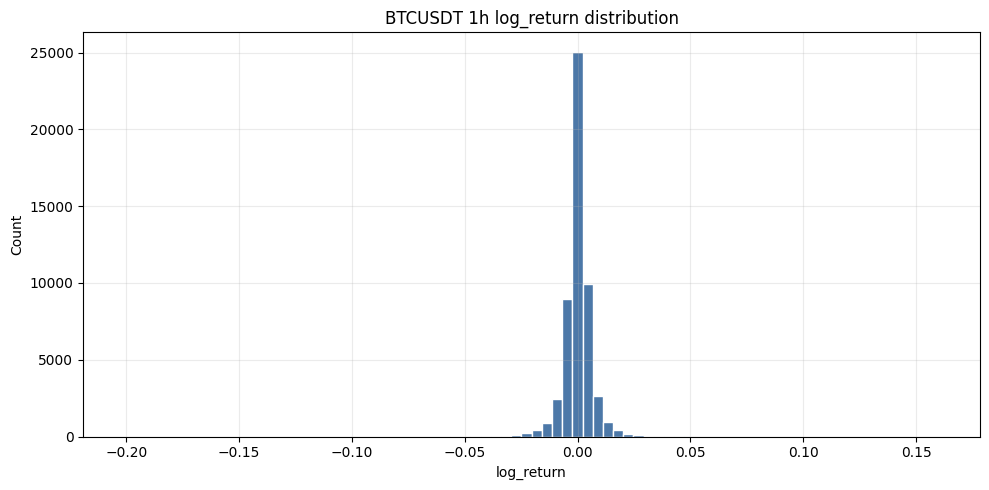

Saved plot: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\dataset_validation\BTCUSDT_1h_log_return_histogram.png


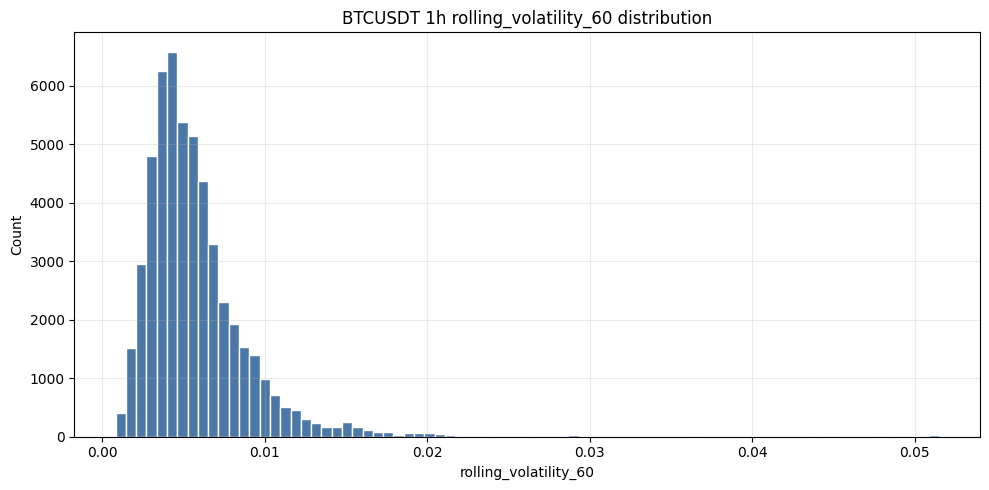

Saved plot: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\dataset_validation\BTCUSDT_1h_rolling_volatility_60_histogram.png


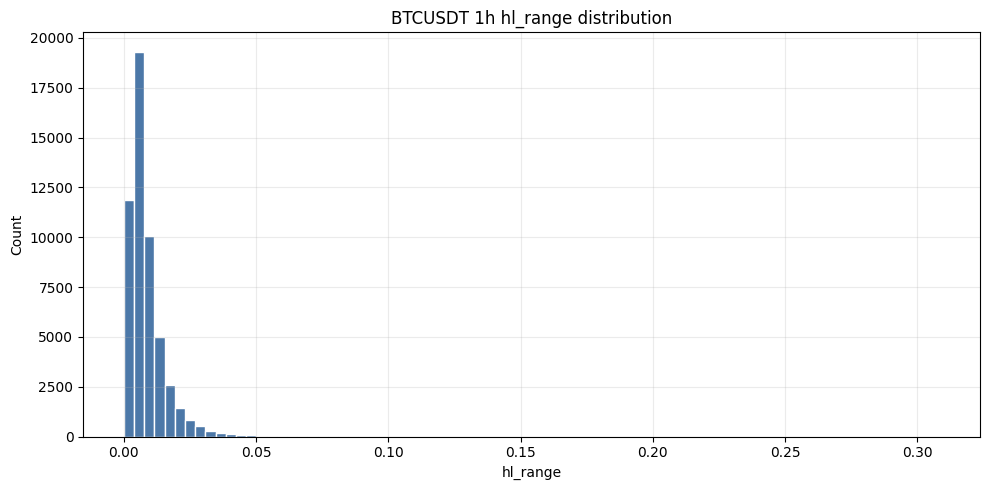

Saved plot: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\dataset_validation\BTCUSDT_1h_hl_range_histogram.png


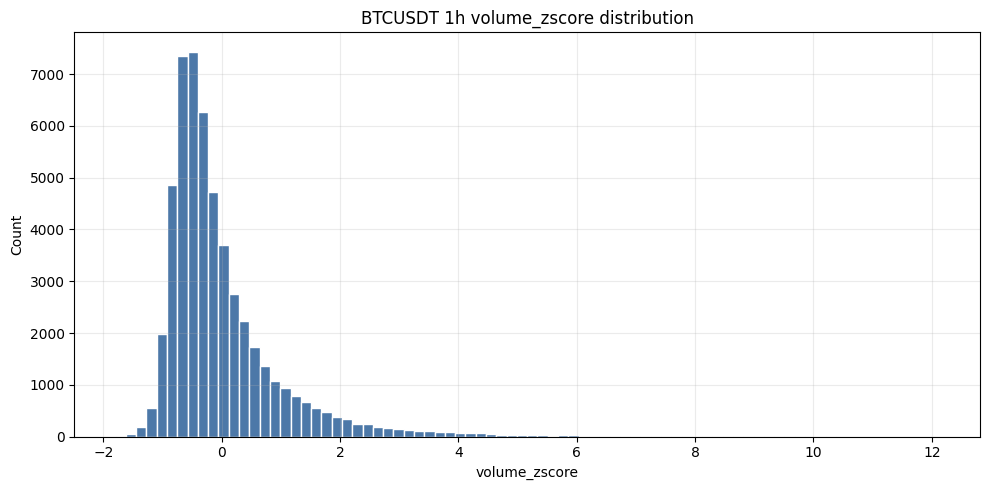

Saved plot: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\dataset_validation\BTCUSDT_1h_volume_zscore_histogram.png


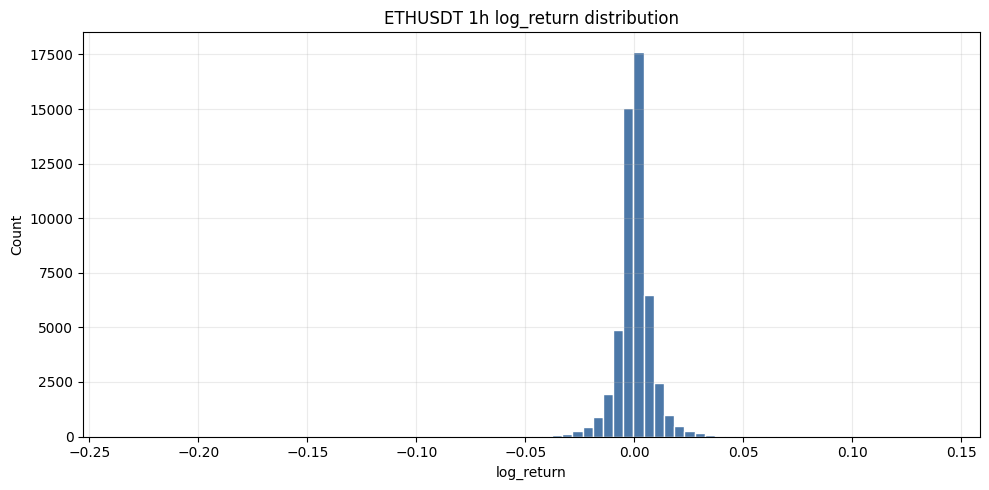

Saved plot: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\dataset_validation\ETHUSDT_1h_log_return_histogram.png


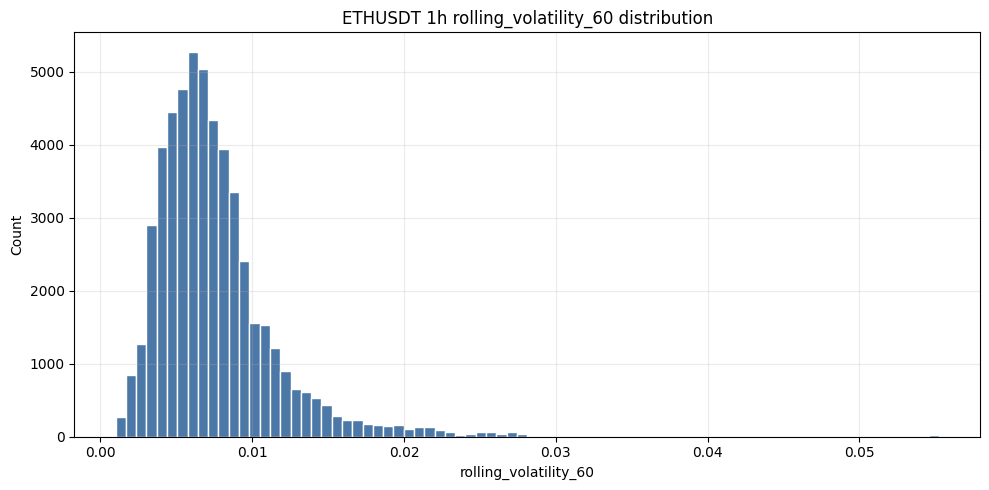

Saved plot: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\dataset_validation\ETHUSDT_1h_rolling_volatility_60_histogram.png


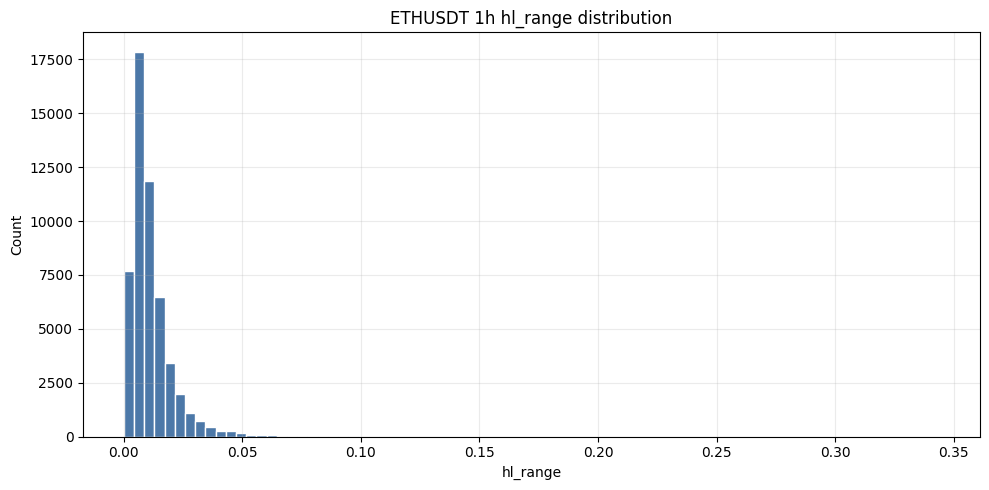

Saved plot: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\dataset_validation\ETHUSDT_1h_hl_range_histogram.png


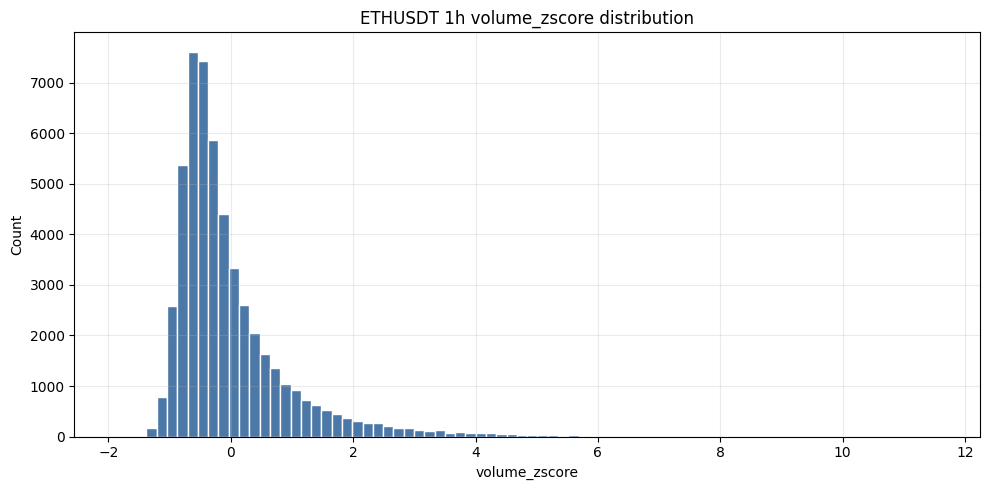

Saved plot: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\dataset_validation\ETHUSDT_1h_volume_zscore_histogram.png


,asset,feature,mean,std,min,q01,q25,median,q75,q99,max,valid_rows
0,BTCUSDT,log_return,0.000048,0.006715,-0.201033,-0.019622,-0.002317,0.000065,0.002509,0.018857,0.160280,52576
1,BTCUSDT,rolling_volatility_60,0.005771,0.003443,0.000807,0.001540,0.003693,0.005041,0.006871,0.017774,0.051487,52557
2,BTCUSDT,hl_range,0.008702,0.008304,0.000000,0.001171,0.004075,0.006535,0.010621,0.038200,0.308296,52577
3,BTCUSDT,volume_zscore,0.005133,1.053090,-1.793307,-1.149481,-0.617407,-0.301025,0.261754,4.223146,12.118744,52545
4,ETHUSDT,log_return,0.000060,0.008653,-0.234113,-0.025423,-0.003158,0.000089,0.003442,0.024829,0.139825,52576
5,ETHUSDT,rolling_volatility_60,0.007564,0.004209,0.000998,0.001948,0.004978,0.006748,0.008920,0.022686,0.055241,52557
6,ETHUSDT,hl_range,0.011454,0.010419,0.000000,0.001668,0.005607,0.008812,0.013976,0.048530,0.343957,52577
7,ETHUSDT,volume_zscore,0.004232,1.058830,-1.884325,-1.114152,-0.610032,-0.309279,0.241131,4.288411,11.573446,52545


WindowsPath('C:/Users/learn/OneDrive/Desktop/Final Masters Thesis/reports/dataset_validation/feature_distribution_summary.csv')

In [10]:
selected_feature_files = {
    "BTCUSDT": FEATURES_DIR / "crypto" / "BTCUSDT_1h_features_2020_2025.parquet",
    "ETHUSDT": FEATURES_DIR / "crypto" / "ETHUSDT_1h_features_2020_2025.parquet",
}
selected_features = ["log_return", "rolling_volatility_60", "hl_range", "volume_zscore"]
crypto_1h_features = {}
distribution_rows = []
for asset, path in selected_feature_files.items():
    frame = ensure_timestamp(safe_read_parquet(path))
    if frame is None:
        continue
    crypto_1h_features[asset] = frame
    for feature in selected_features:
        values = pd.to_numeric(frame[feature], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
        distribution_rows.append({"asset": asset, "feature": feature, "mean": values.mean(), "std": values.std(), "min": values.min(), "q01": values.quantile(0.01), "q25": values.quantile(0.25), "median": values.median(), "q75": values.quantile(0.75), "q99": values.quantile(0.99), "max": values.max(), "valid_rows": len(values)})
        plt.figure()
        plt.hist(values, bins=80, color="#4C78A8", edgecolor="white")
        plt.xlabel(feature)
        plt.ylabel("Count")
        plt.title(f"{asset} 1h {feature} distribution")
        save_current_plot(f"{asset}_1h_{feature}_histogram")
feature_distribution_summary_df = pd.DataFrame(distribution_rows)
display(feature_distribution_summary_df)
save_table("feature_distribution_summary", feature_distribution_summary_df)

# 12. Simple volatility regime preview

This is only a validation preview, not the final regime model. It uses 1-hour `rolling_volatility_60` and splits observations into low, medium, and high volatility regimes using the 33rd and 66th percentiles.

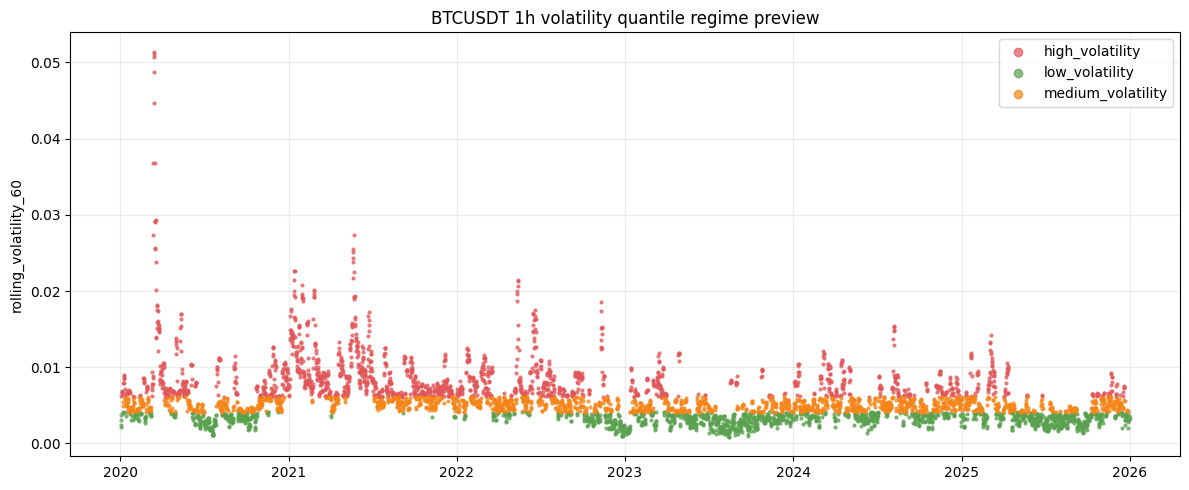

Saved plot: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\dataset_validation\BTCUSDT_1h_volatility_regime_preview.png


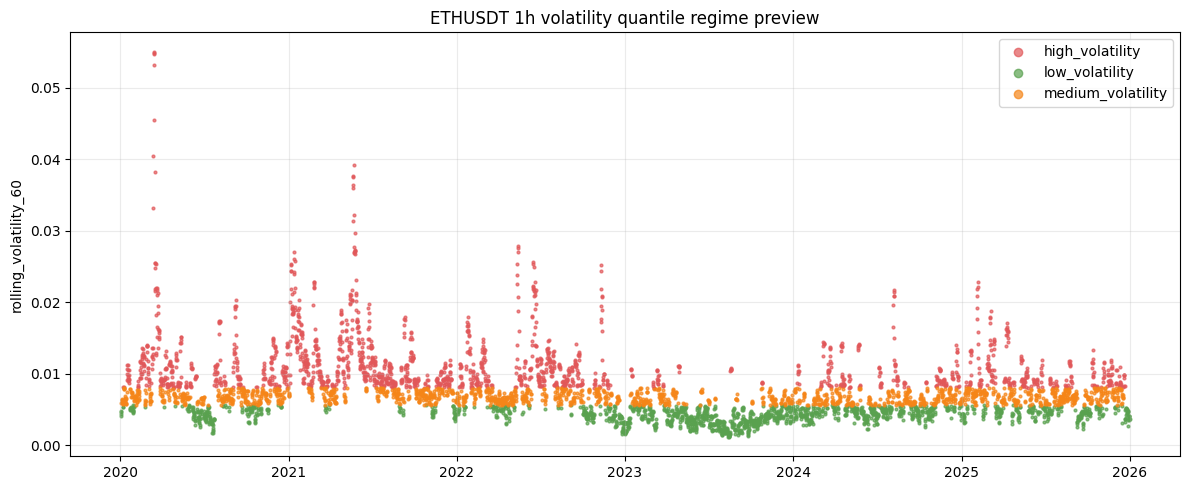

Saved plot: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\dataset_validation\ETHUSDT_1h_volatility_regime_preview.png


,regime,count,asset,percentage
0,high_volatility,17870,BTCUSDT,33.988246
1,low_volatility,17344,BTCUSDT,32.987808
2,medium_volatility,17343,BTCUSDT,32.985906
3,NaN,20,BTCUSDT,0.038039
4,high_volatility,17870,ETHUSDT,33.988246
5,low_volatility,17344,ETHUSDT,32.987808
6,medium_volatility,17343,ETHUSDT,32.985906
7,NaN,20,ETHUSDT,0.038039


WindowsPath('C:/Users/learn/OneDrive/Desktop/Final Masters Thesis/reports/dataset_validation/volatility_regime_preview_counts.csv')

In [11]:
regime_rows = []
colors = {"low_volatility": "#59A14F", "medium_volatility": "#F58518", "high_volatility": "#E15759"}
for asset, frame in crypto_1h_features.items():
    preview = frame[["timestamp", "rolling_volatility_60"]].copy()
    vol = pd.to_numeric(preview["rolling_volatility_60"], errors="coerce")
    q33, q66 = vol.quantile(0.33), vol.quantile(0.66)
    preview["volatility_regime_preview"] = np.select([vol <= q33, vol <= q66, vol > q66], ["low_volatility", "medium_volatility", "high_volatility"], default="missing")
    preview.loc[vol.isna(), "volatility_regime_preview"] = pd.NA
    preview.to_csv(OUTPUT_DIR / f"{asset}_1h_volatility_quantile_preview.csv", index=False)
    counts = preview["volatility_regime_preview"].value_counts(dropna=False).rename_axis("regime").reset_index(name="count")
    counts["asset"] = asset
    counts["percentage"] = counts["count"] / len(preview) * 100
    regime_rows.append(counts)
    sample = preview.dropna().iloc[::max(1, len(preview) // 5000)]
    plt.figure(figsize=(12, 5))
    for regime, group in sample.groupby("volatility_regime_preview"):
        plt.scatter(group["timestamp"], group["rolling_volatility_60"], s=4, color=colors.get(regime, "gray"), label=regime, alpha=0.7)
    plt.ylabel("rolling_volatility_60")
    plt.title(f"{asset} 1h volatility quantile regime preview")
    plt.legend(markerscale=3)
    save_current_plot(f"{asset}_1h_volatility_regime_preview")

regime_count_df = pd.concat(regime_rows, ignore_index=True) if regime_rows else pd.DataFrame()
display(regime_count_df)
save_table("volatility_regime_preview_counts", regime_count_df)

# 13. HMM feature matrix readiness preview

This section verifies that a clean feature matrix can be built for HMM training using return, volatility, range, and activity features. It does not train an HMM.

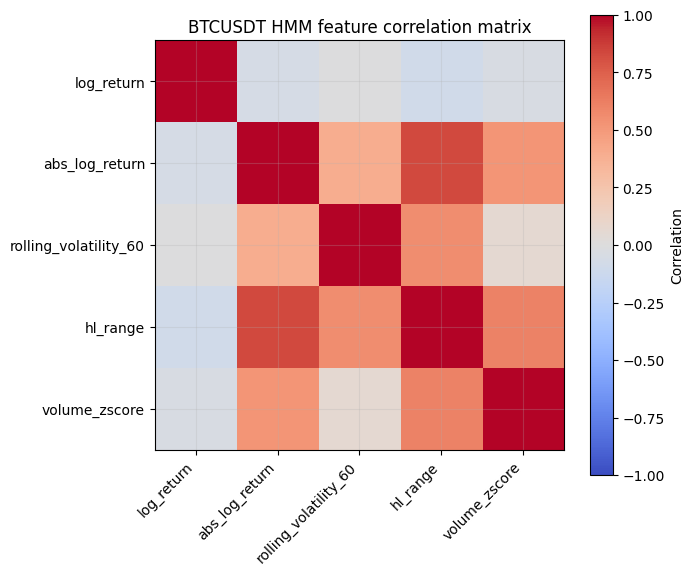

Saved plot: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\dataset_validation\BTCUSDT_hmm_feature_correlation_heatmap.png


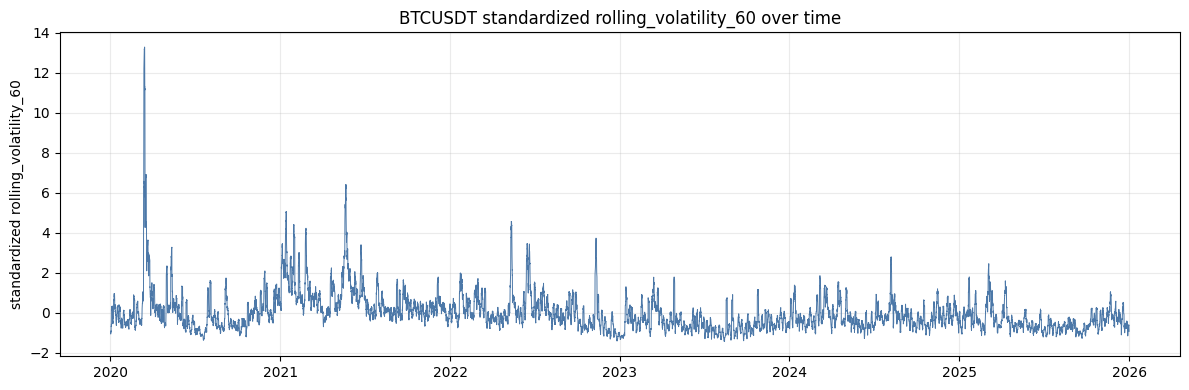

Saved plot: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\dataset_validation\BTCUSDT_standardized_rolling_volatility_60.png


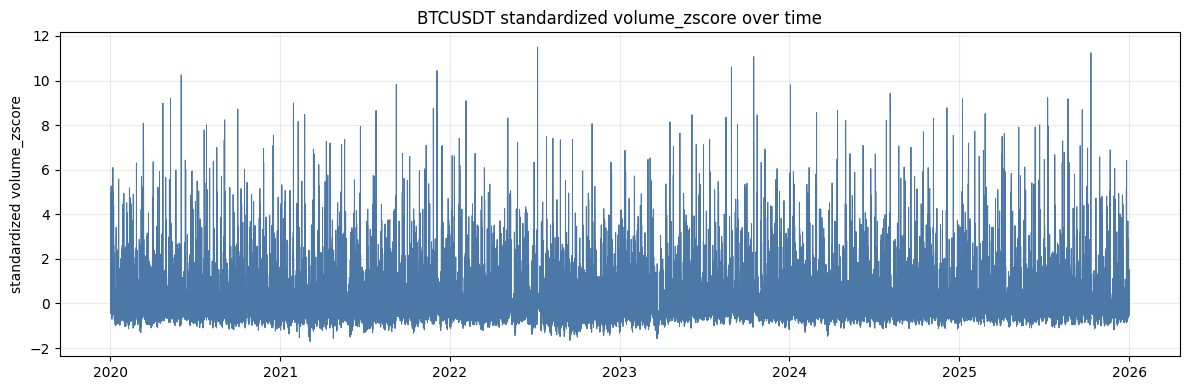

Saved plot: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\dataset_validation\BTCUSDT_standardized_volume_zscore.png


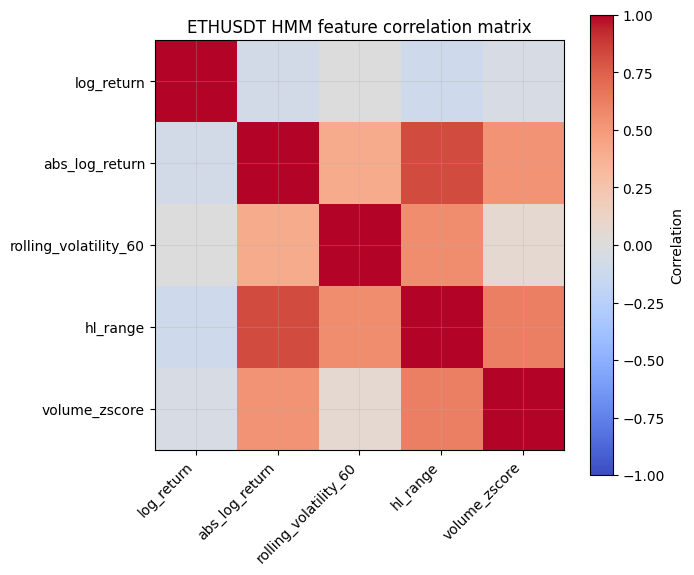

Saved plot: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\dataset_validation\ETHUSDT_hmm_feature_correlation_heatmap.png


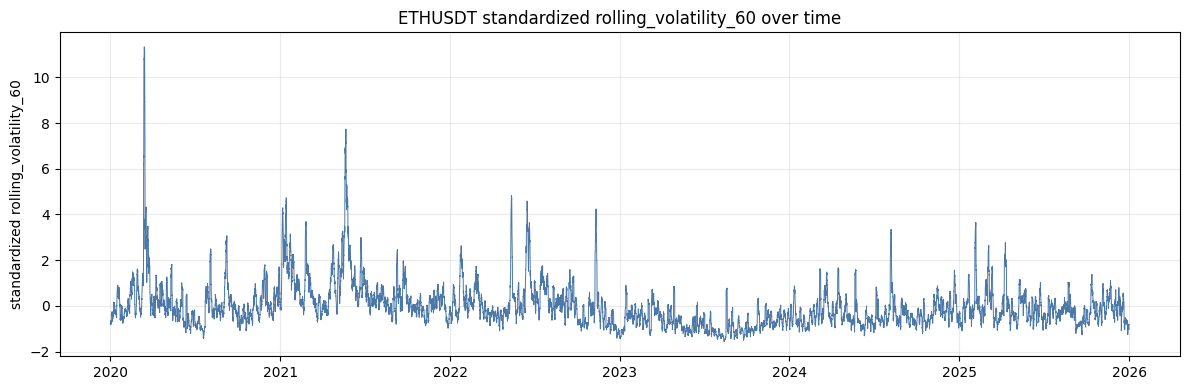

Saved plot: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\dataset_validation\ETHUSDT_standardized_rolling_volatility_60.png


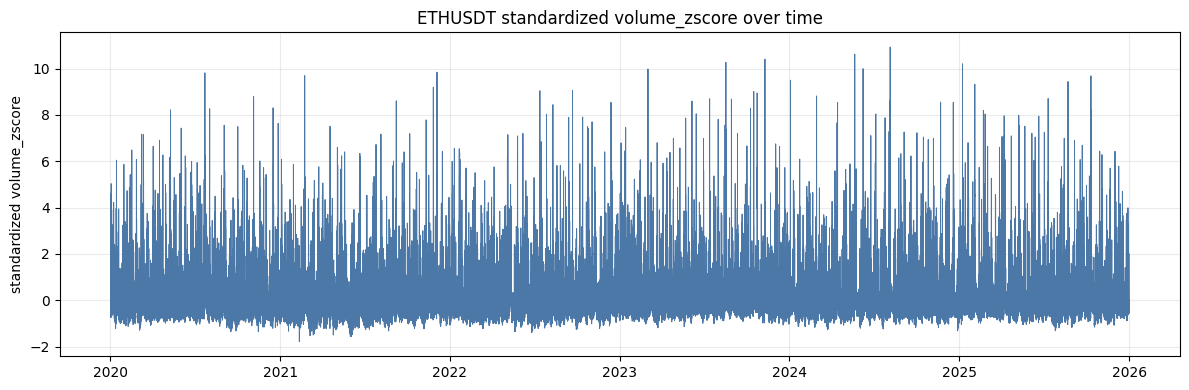

Saved plot: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\dataset_validation\ETHUSDT_standardized_volume_zscore.png


,asset,features_available,rows_before_dropna,rows_after_dropna,percentage_retained,infinite_values,nan_values_before_dropna
0,BTCUSDT,5,52577,52545,99.939137,0,54
1,ETHUSDT,5,52577,52545,99.939137,0,54


WindowsPath('C:/Users/learn/OneDrive/Desktop/Final Masters Thesis/reports/dataset_validation/hmm_feature_matrix_readiness.csv')

In [12]:
hmm_features = ["log_return", "abs_log_return", "rolling_volatility_60", "hl_range", "volume_zscore"]
hmm_rows = []
hmm_matrices = {}
for asset, frame in crypto_1h_features.items():
    available = [c for c in hmm_features if c in frame.columns]
    matrix = frame[["timestamp"] + available].copy()
    raw = matrix[available].apply(pd.to_numeric, errors="coerce")
    inf_count = int(np.isinf(raw.to_numpy(dtype=float)).sum())
    raw = raw.replace([np.inf, -np.inf], np.nan)
    nan_count = int(raw.isna().sum().sum())
    clean = raw.dropna()
    hmm_matrices[asset] = clean
    hmm_rows.append({"asset": asset, "features_available": len(available), "rows_before_dropna": len(raw), "rows_after_dropna": len(clean), "percentage_retained": len(clean) / len(raw) * 100, "infinite_values": inf_count, "nan_values_before_dropna": nan_count})
    corr = clean.corr()
    plt.figure(figsize=(7, 6))
    plt.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
    plt.colorbar(label="Correlation")
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
    plt.yticks(range(len(corr.index)), corr.index)
    plt.title(f"{asset} HMM feature correlation matrix")
    save_current_plot(f"{asset}_hmm_feature_correlation_heatmap")
    for feature in ["rolling_volatility_60", "volume_zscore"]:
        z = (raw[feature] - raw[feature].mean()) / raw[feature].std()
        plt.figure(figsize=(12, 4))
        plt.plot(matrix["timestamp"], z, linewidth=0.7, color="#4C78A8")
        plt.ylabel(f"standardized {feature}")
        plt.title(f"{asset} standardized {feature} over time")
        save_current_plot(f"{asset}_standardized_{feature}")

hmm_readiness_df = pd.DataFrame(hmm_rows)
display(hmm_readiness_df)
save_table("hmm_feature_matrix_readiness", hmm_readiness_df)

# 14. Cross-market validation data audit

FX, equity indices, and VIX are not the computational core. They are used for cross-market regime validation and broader market context.

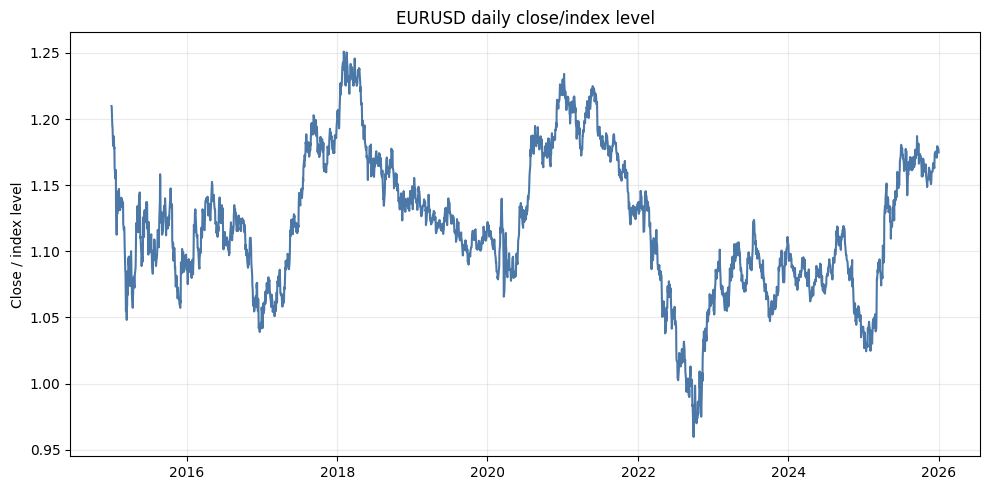

Saved plot: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\dataset_validation\EURUSD_daily_close_level.png


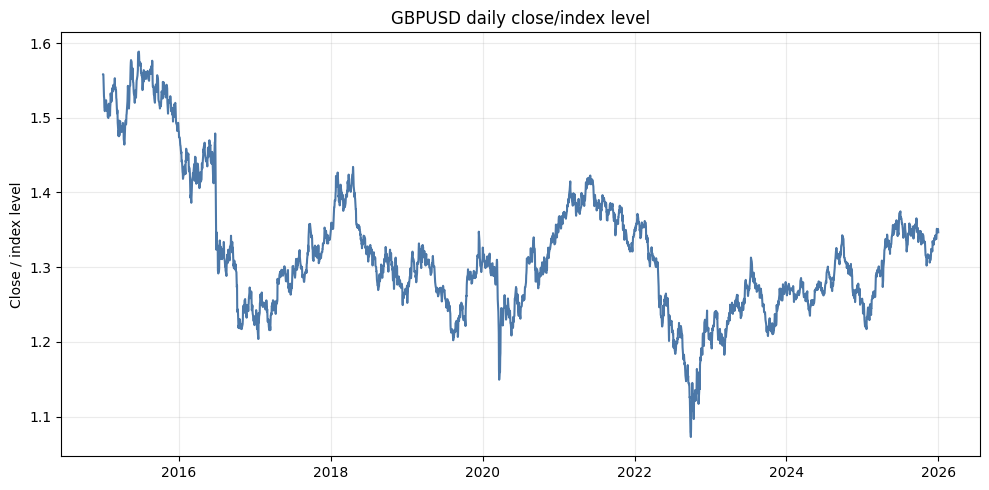

Saved plot: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\dataset_validation\GBPUSD_daily_close_level.png


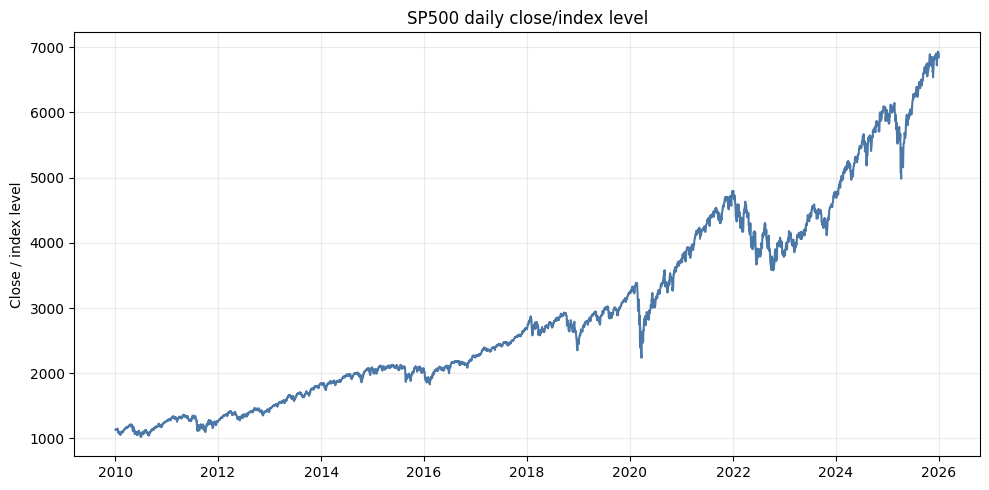

Saved plot: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\dataset_validation\SP500_daily_close_level.png


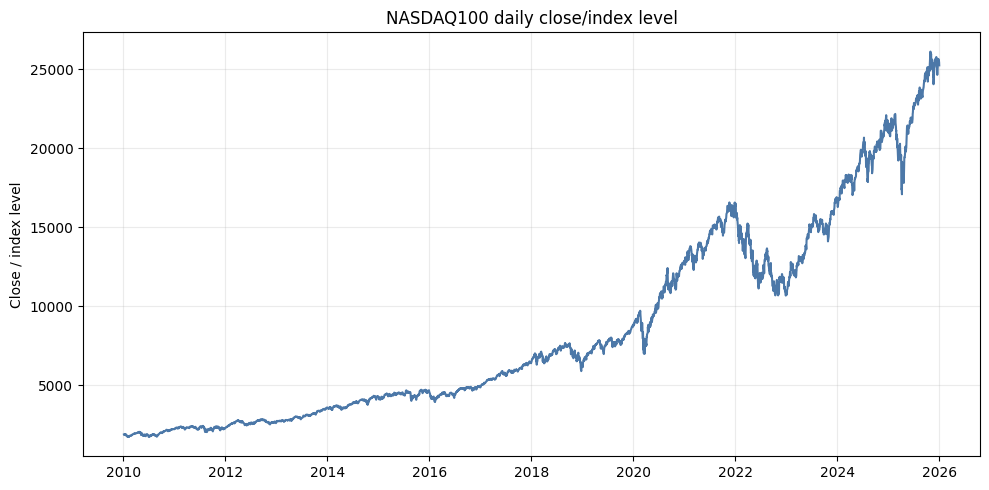

Saved plot: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\dataset_validation\NASDAQ100_daily_close_level.png


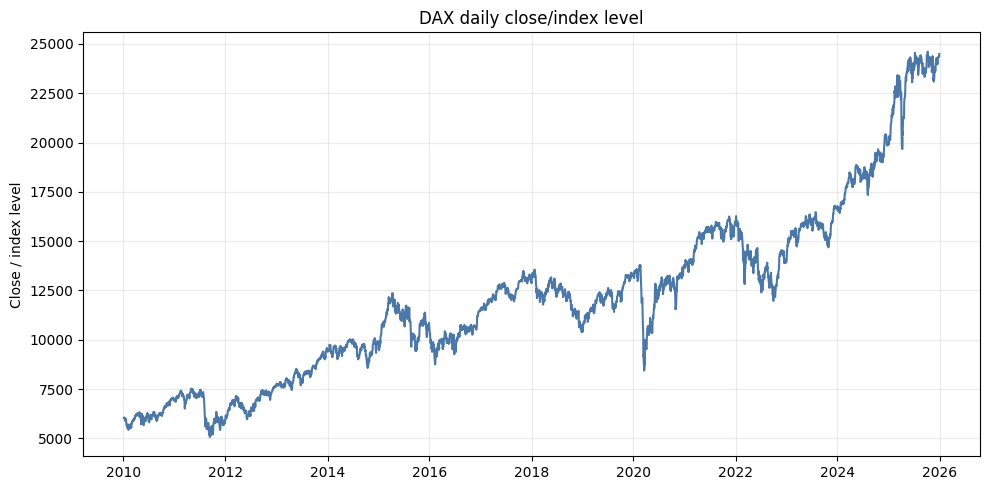

Saved plot: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\dataset_validation\DAX_daily_close_level.png


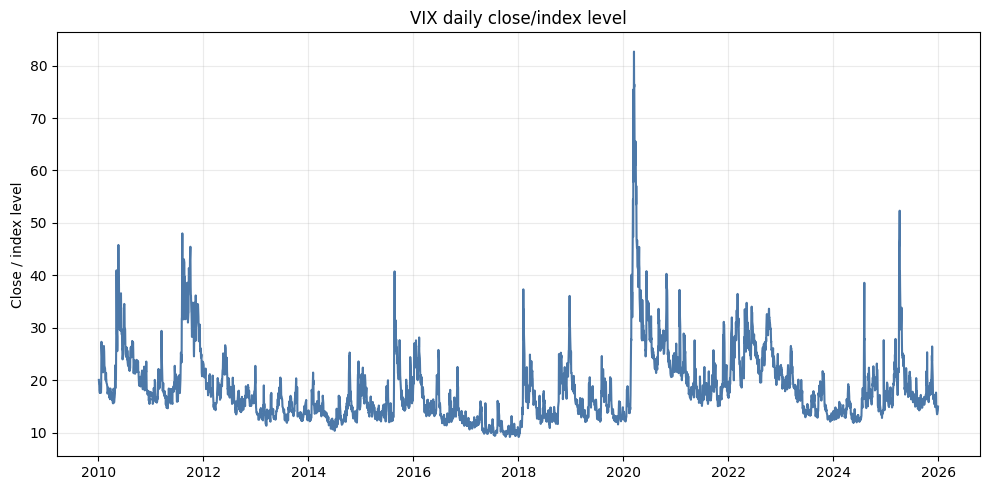

Saved plot: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\dataset_validation\VIX_daily_close_level.png


,dataset,rows,start,end,missing_values,duplicate_timestamps,file_size_mb
0,EURUSD,2863,2015-01-01 00:00:00+00:00,2025-12-31 00:00:00+00:00,0,0,0.116
1,GBPUSD,2863,2015-01-01 00:00:00+00:00,2025-12-31 00:00:00+00:00,0,0,0.118
2,SP500,4024,2010-01-04 00:00:00+00:00,2025-12-31 00:00:00+00:00,0,0,0.210
3,NASDAQ100,4024,2010-01-04 00:00:00+00:00,2025-12-31 00:00:00+00:00,0,0,0.211
4,DAX,4059,2010-01-04 00:00:00+00:00,2025-12-30 00:00:00+00:00,0,0,0.212
5,VIX,4024,2010-01-04 00:00:00+00:00,2025-12-31 00:00:00+00:00,0,0,0.114


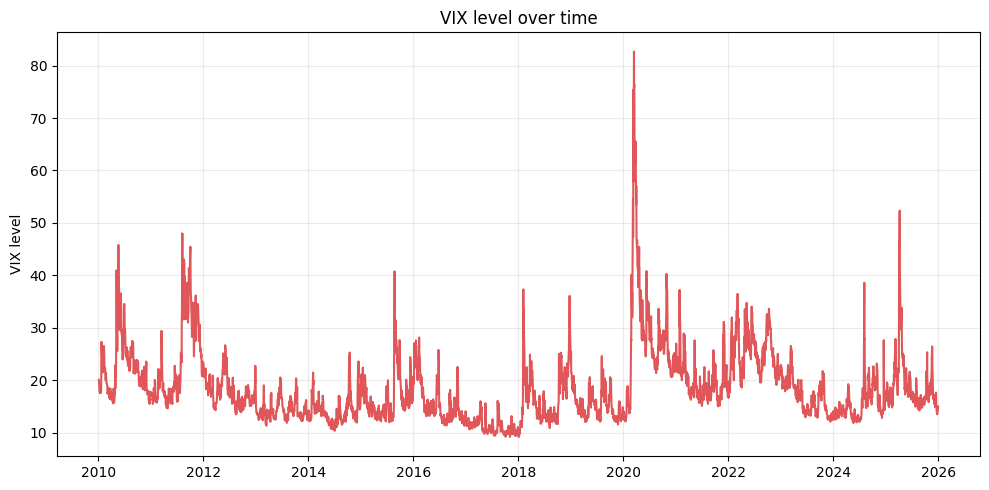

Saved plot: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\dataset_validation\VIX_level_over_time.png


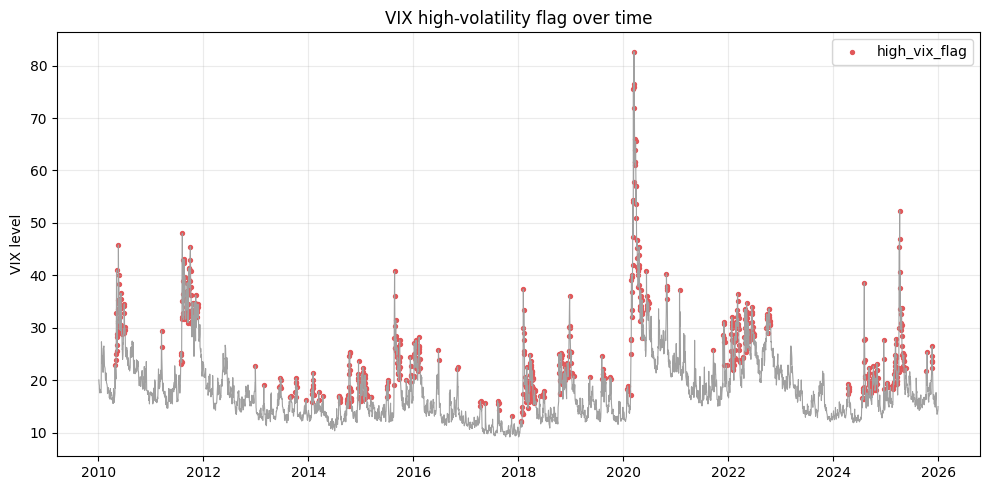

Saved plot: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\dataset_validation\VIX_high_volatility_flag.png


In [13]:
market_files = {
    "EURUSD": PROCESSED_DIR / "fx" / "EURUSD_1d_2015_2025.parquet",
    "GBPUSD": PROCESSED_DIR / "fx" / "GBPUSD_1d_2015_2025.parquet",
    "SP500": PROCESSED_DIR / "equity_indices" / "SP500_1d_2010_2025.parquet",
    "NASDAQ100": PROCESSED_DIR / "equity_indices" / "NASDAQ100_1d_2010_2025.parquet",
    "DAX": PROCESSED_DIR / "equity_indices" / "DAX_1d_2010_2025.parquet",
    "VIX": PROCESSED_DIR / "volatility" / "VIX_1d_2010_2025.parquet",
}
market_rows, market_frames = [], {}
for name, path in market_files.items():
    frame = ensure_timestamp(safe_read_parquet(path))
    if frame is None:
        continue
    market_frames[name] = frame
    market_rows.append({"dataset": name, "rows": len(frame), "start": frame["timestamp"].min(), "end": frame["timestamp"].max(), "missing_values": int(frame.isna().sum().sum()), "duplicate_timestamps": int(frame["timestamp"].duplicated().sum()), "file_size_mb": file_size_mb(path)})
    plt.figure()
    plt.plot(frame["timestamp"], frame["close"], color="#4C78A8")
    plt.ylabel("Close / index level")
    plt.title(f"{name} daily close/index level")
    save_current_plot(f"{name}_daily_close_level")

market_audit_df = pd.DataFrame(market_rows)
display(market_audit_df)
save_table("cross_market_data_audit", market_audit_df)

vix_features = ensure_timestamp(safe_read_parquet(FEATURES_DIR / "volatility" / "VIX_1d_features_2010_2025.parquet"))
if vix_features is not None and {"vix_level", "high_vix_flag"}.issubset(vix_features.columns):
    flagged = vix_features[vix_features["high_vix_flag"] == 1]
    plt.figure()
    plt.plot(vix_features["timestamp"], vix_features["vix_level"], color="#E15759")
    plt.ylabel("VIX level")
    plt.title("VIX level over time")
    save_current_plot("VIX_level_over_time")
    plt.figure()
    plt.plot(vix_features["timestamp"], vix_features["vix_level"], color="#A0A0A0", linewidth=0.8)
    plt.scatter(flagged["timestamp"], flagged["vix_level"], s=8, color="#E15759", label="high_vix_flag")
    plt.ylabel("VIX level")
    plt.title("VIX high-volatility flag over time")
    plt.legend()
    save_current_plot("VIX_high_volatility_flag")

# 15. Cross-asset date alignment check

Date alignment matters for external validation and event comparison. This section checks daily availability from 2020-01-01 to 2025-12-31 across crypto daily bars, FX, equity indices, and VIX.

,asset,available_dates,total_dates,coverage_pct
0,BTCUSDT_daily,2192,2192,100.000000
1,ETHUSDT_daily,2192,2192,100.000000
2,EURUSD_daily,1562,2192,71.259124
3,GBPUSD_daily,1562,2192,71.259124
4,SP500_daily,1508,2192,68.795620
5,NASDAQ100_daily,1508,2192,68.795620
6,DAX_daily,1528,2192,69.708029
7,VIX_daily,1508,2192,68.795620


,scope,overlapping_dates
0,all_daily_datasets,1486
1,crypto_plus_vix,1508
2,equity_plus_vix,1486


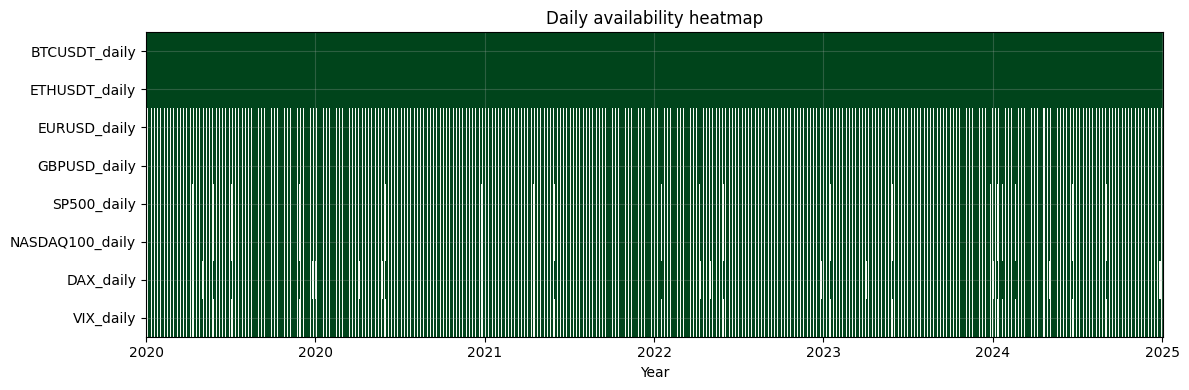

Saved plot: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\dataset_validation\daily_availability_heatmap.png


WindowsPath('C:/Users/learn/OneDrive/Desktop/Final Masters Thesis/reports/dataset_validation/daily_availability_heatmap.png')

In [14]:
daily_index = pd.date_range("2020-01-01", "2025-12-31", freq="D", tz="UTC")
daily_files = {
    "BTCUSDT_daily": PROCESSED_DIR / "crypto" / "1d" / "BTCUSDT_1d_2020_2025.parquet",
    "ETHUSDT_daily": PROCESSED_DIR / "crypto" / "1d" / "ETHUSDT_1d_2020_2025.parquet",
    "EURUSD_daily": market_files["EURUSD"],
    "GBPUSD_daily": market_files["GBPUSD"],
    "SP500_daily": market_files["SP500"],
    "NASDAQ100_daily": market_files["NASDAQ100"],
    "DAX_daily": market_files["DAX"],
    "VIX_daily": market_files["VIX"],
}
availability, rows = {}, []
for name, path in daily_files.items():
    frame = ensure_timestamp(safe_read_parquet(path, columns=["timestamp"]))
    if frame is None:
        available = pd.Series(False, index=daily_index)
    else:
        dates = frame["timestamp"].dt.normalize().drop_duplicates()
        available = pd.Series(daily_index.isin(pd.DatetimeIndex(dates)), index=daily_index)
    availability[name] = available
    rows.append({"asset": name, "available_dates": int(available.sum()), "total_dates": len(daily_index), "coverage_pct": available.mean() * 100})
alignment_coverage_df = pd.DataFrame(rows)
availability_df = pd.DataFrame(availability)
overlap_all = int(availability_df.all(axis=1).sum())
overlap_crypto_vix = int(availability_df[["BTCUSDT_daily", "ETHUSDT_daily", "VIX_daily"]].all(axis=1).sum())
overlap_equity_vix = int(availability_df[["SP500_daily", "NASDAQ100_daily", "DAX_daily", "VIX_daily"]].all(axis=1).sum())
daily_overlap_summary_df = pd.DataFrame([
    {"scope": "all_daily_datasets", "overlapping_dates": overlap_all},
    {"scope": "crypto_plus_vix", "overlapping_dates": overlap_crypto_vix},
    {"scope": "equity_plus_vix", "overlapping_dates": overlap_equity_vix},
])
display(alignment_coverage_df)
display(daily_overlap_summary_df)
save_table("daily_alignment_coverage", alignment_coverage_df)
save_table("daily_overlap_summary", daily_overlap_summary_df)

plt.figure(figsize=(12, 4))
plt.imshow(availability_df.T.astype(int), aspect="auto", cmap="Greens", interpolation="nearest")
plt.yticks(range(len(availability_df.columns)), availability_df.columns)
ticks = np.linspace(0, len(daily_index) - 1, 7).astype(int)
plt.xticks(ticks, [daily_index[i].year for i in ticks])
plt.xlabel("Year")
plt.title("Daily availability heatmap")
save_current_plot("daily_availability_heatmap")

# 16. Interesting data science validation: volatility clustering evidence

Volatility clustering supports the need for regime detection. This section computes autocorrelation for absolute returns and rolling volatility over lags 1 to 48.

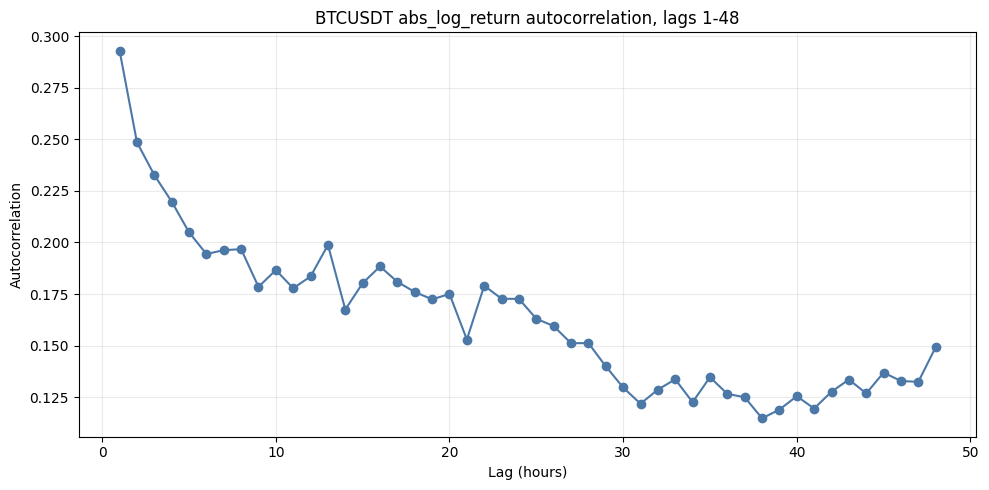

Saved plot: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\dataset_validation\BTCUSDT_abs_log_return_autocorrelation_lags_1_48.png


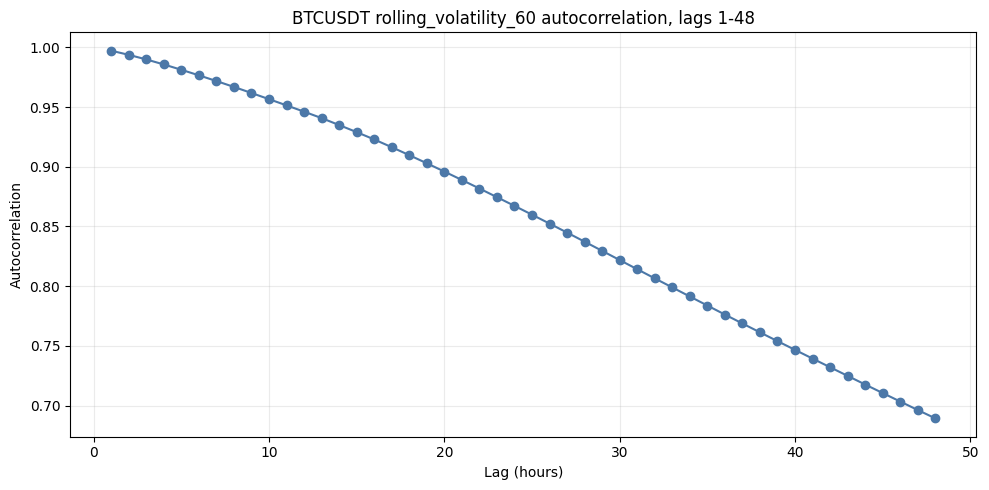

Saved plot: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\dataset_validation\BTCUSDT_rolling_volatility_60_autocorrelation_lags_1_48.png


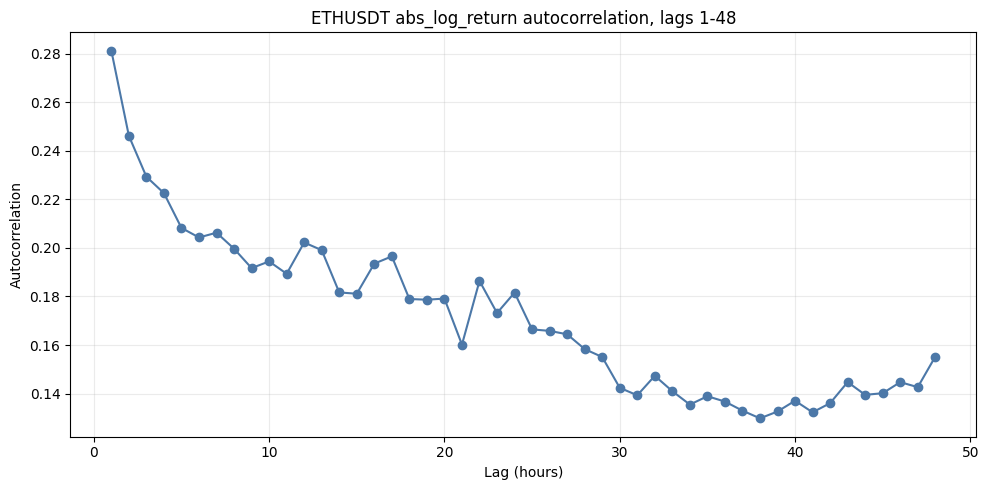

Saved plot: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\dataset_validation\ETHUSDT_abs_log_return_autocorrelation_lags_1_48.png


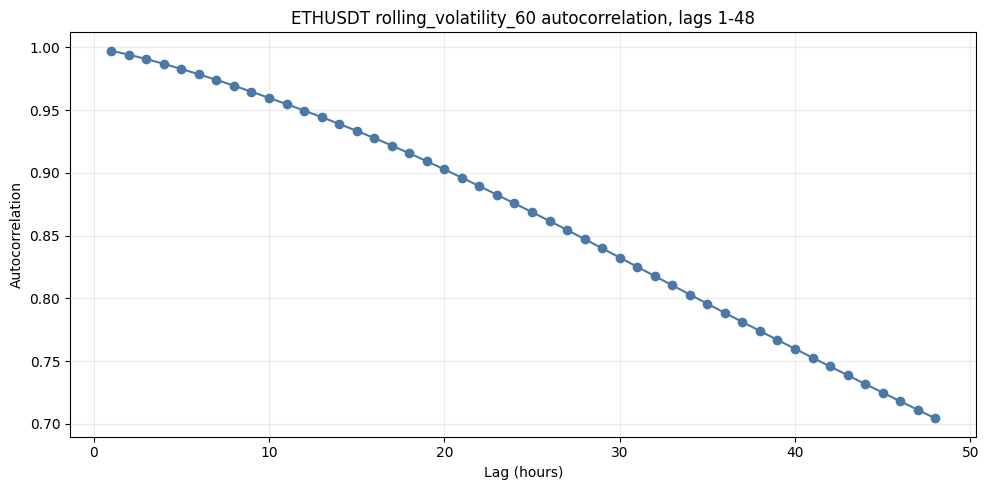

Saved plot: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\dataset_validation\ETHUSDT_rolling_volatility_60_autocorrelation_lags_1_48.png


,asset,feature,lag,autocorrelation
0,BTCUSDT,abs_log_return,1,0.292993
1,BTCUSDT,abs_log_return,2,0.248594
2,BTCUSDT,abs_log_return,3,0.232695
3,BTCUSDT,abs_log_return,4,0.219840
4,BTCUSDT,abs_log_return,5,0.204942


WindowsPath('C:/Users/learn/OneDrive/Desktop/Final Masters Thesis/reports/dataset_validation/volatility_clustering_autocorrelation.csv')

In [15]:
autocorr_rows = []
for asset, frame in crypto_1h_features.items():
    for feature in ["abs_log_return", "rolling_volatility_60"]:
        series = pd.to_numeric(frame[feature], errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
        lags = list(range(1, 49))
        values = [series.autocorr(lag=lag) for lag in lags]
        autocorr_rows.extend({"asset": asset, "feature": feature, "lag": lag, "autocorrelation": val} for lag, val in zip(lags, values))
        plt.figure()
        plt.plot(lags, values, marker="o", color="#4C78A8")
        plt.xlabel("Lag (hours)")
        plt.ylabel("Autocorrelation")
        plt.title(f"{asset} {feature} autocorrelation, lags 1-48")
        save_current_plot(f"{asset}_{feature}_autocorrelation_lags_1_48")
autocorrelation_df = pd.DataFrame(autocorr_rows)
display(autocorrelation_df.head())
save_table("volatility_clustering_autocorrelation", autocorrelation_df)

# 17. Interesting data science validation: BTC vs ETH co-movement

Changing BTC/ETH correlation supports the nonstationarity motivation of the thesis. This section aligns hourly returns and computes rolling 30-day and 7-day correlations.

Aligned BTC/ETH hourly log-return correlation: 0.8396


,metric,value,aligned_rows
0,aligned_log_return_correlation,0.839567,52576


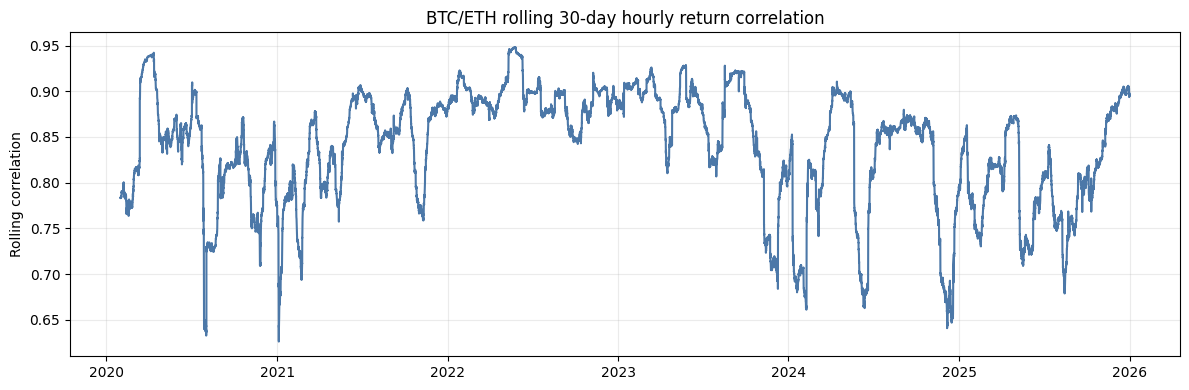

Saved plot: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\dataset_validation\BTC_ETH_rolling_30d_return_correlation.png


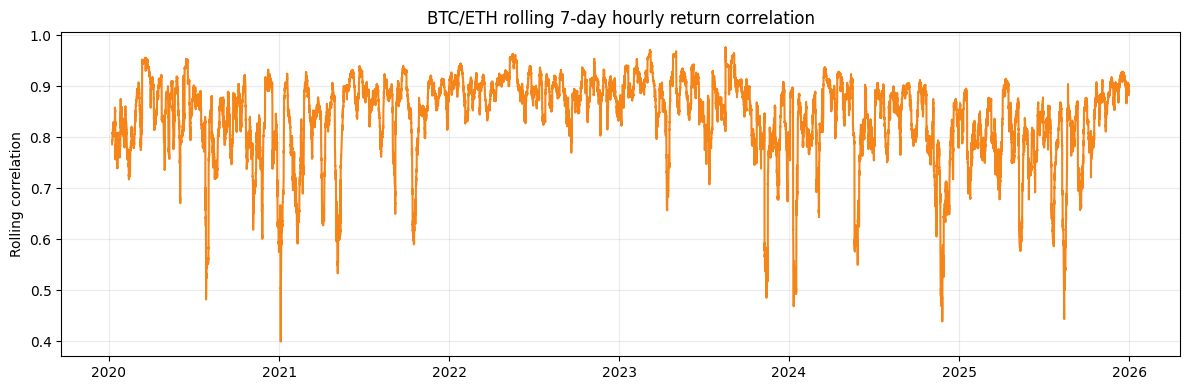

Saved plot: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\dataset_validation\BTC_ETH_rolling_7d_return_correlation.png


WindowsPath('C:/Users/learn/OneDrive/Desktop/Final Masters Thesis/reports/dataset_validation/BTC_ETH_rolling_7d_return_correlation.png')

In [16]:
btc = crypto_1h_features["BTCUSDT"][["timestamp", "log_return"]].rename(columns={"log_return": "BTC_log_return"})
eth = crypto_1h_features["ETHUSDT"][["timestamp", "log_return"]].rename(columns={"log_return": "ETH_log_return"})
aligned_returns = btc.merge(eth, on="timestamp", how="inner").dropna()
aligned_log_return_correlation = aligned_returns["BTC_log_return"].corr(aligned_returns["ETH_log_return"])
aligned_returns["rolling_corr_30d"] = aligned_returns["BTC_log_return"].rolling(24 * 30).corr(aligned_returns["ETH_log_return"])
aligned_returns["rolling_corr_7d"] = aligned_returns["BTC_log_return"].rolling(24 * 7).corr(aligned_returns["ETH_log_return"])
btc_eth_comovement_summary_df = pd.DataFrame([{"metric": "aligned_log_return_correlation", "value": aligned_log_return_correlation, "aligned_rows": len(aligned_returns)}])
print(f"Aligned BTC/ETH hourly log-return correlation: {aligned_log_return_correlation:.4f}")
display(btc_eth_comovement_summary_df)
save_table("btc_eth_comovement_summary", btc_eth_comovement_summary_df)

plt.figure(figsize=(12, 4))
plt.plot(aligned_returns["timestamp"], aligned_returns["rolling_corr_30d"], color="#4C78A8")
plt.ylabel("Rolling correlation")
plt.title("BTC/ETH rolling 30-day hourly return correlation")
save_current_plot("BTC_ETH_rolling_30d_return_correlation")

plt.figure(figsize=(12, 4))
plt.plot(aligned_returns["timestamp"], aligned_returns["rolling_corr_7d"], color="#F58518")
plt.ylabel("Rolling correlation")
plt.title("BTC/ETH rolling 7-day hourly return correlation")
save_current_plot("BTC_ETH_rolling_7d_return_correlation")

# 18. Interesting data science validation: VIX external stress proxy

VIX is used only for external validation, not as a training label for crypto regime detection. This section previews high-stress days from VIX daily features.

,q80,q90,q95,high_vix_days_ge_q80
0,22.402,26.898,31.370001,805


,timestamp,vix_level
2566,2020-03-16 00:00:00+00:00,82.690002
2568,2020-03-18 00:00:00+00:00,76.449997
2567,2020-03-17 00:00:00+00:00,75.910004
2564,2020-03-12 00:00:00+00:00,75.470001
2569,2020-03-19 00:00:00+00:00,72.000000
2570,2020-03-20 00:00:00+00:00,66.040001
2575,2020-03-27 00:00:00+00:00,65.540001
2573,2020-03-25 00:00:00+00:00,63.950001
2572,2020-03-24 00:00:00+00:00,61.669998
2571,2020-03-23 00:00:00+00:00,61.590000


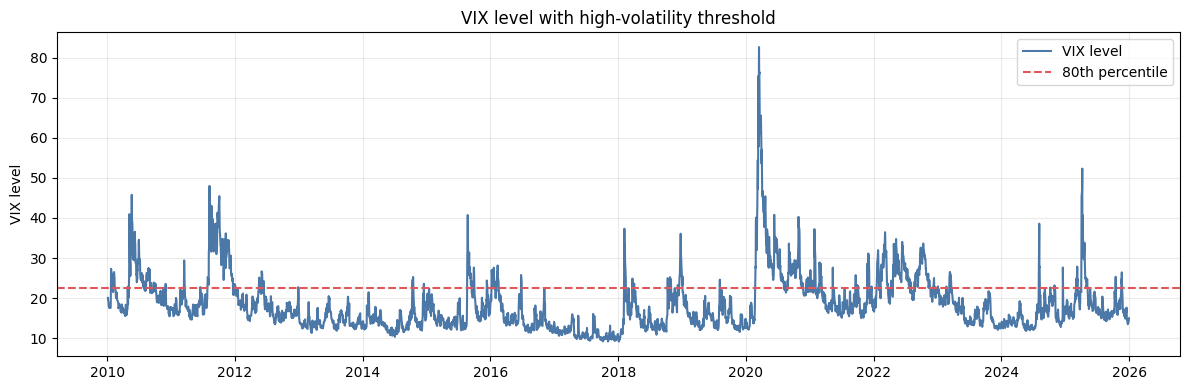

Saved plot: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\dataset_validation\VIX_level_with_high_threshold.png


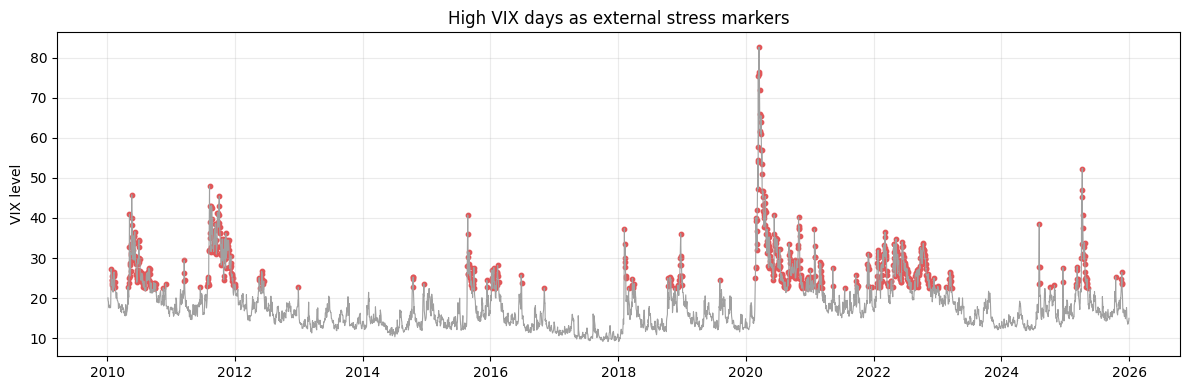

Saved plot: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\dataset_validation\VIX_high_stress_markers.png


WindowsPath('C:/Users/learn/OneDrive/Desktop/Final Masters Thesis/reports/dataset_validation/top_20_vix_days.csv')

In [17]:
if vix_features is not None and "vix_level" in vix_features.columns:
    vix = vix_features.copy()
    level = pd.to_numeric(vix["vix_level"], errors="coerce")
    q80, q90, q95 = level.quantile([0.80, 0.90, 0.95])
    high_vix_days = int((level >= q80).sum())
    vix_threshold_summary_df = pd.DataFrame([{"q80": q80, "q90": q90, "q95": q95, "high_vix_days_ge_q80": high_vix_days}])
    top_vix_days_df = vix[["timestamp", "vix_level"]].sort_values("vix_level", ascending=False).head(20)
    display(vix_threshold_summary_df)
    display(top_vix_days_df)
    plt.figure(figsize=(12, 4))
    plt.plot(vix["timestamp"], level, color="#4C78A8", label="VIX level")
    plt.axhline(q80, color="#E15759", linestyle="--", label="80th percentile")
    plt.ylabel("VIX level")
    plt.title("VIX level with high-volatility threshold")
    plt.legend()
    save_current_plot("VIX_level_with_high_threshold")
    flagged = vix[level >= q80]
    plt.figure(figsize=(12, 4))
    plt.plot(vix["timestamp"], level, color="#A0A0A0", linewidth=0.8)
    plt.scatter(flagged["timestamp"], flagged["vix_level"], s=10, color="#E15759")
    plt.ylabel("VIX level")
    plt.title("High VIX days as external stress markers")
    save_current_plot("VIX_high_stress_markers")
else:
    vix_threshold_summary_df = pd.DataFrame()
    top_vix_days_df = pd.DataFrame()
save_table("vix_threshold_summary", vix_threshold_summary_df)
save_table("top_20_vix_days", top_vix_days_df)

# 19. Final dataset readiness scorecard

Core crypto 1-minute coverage is marked **Ready with documented caveat** because a small fraction of 1-minute timestamps are missing and documented. Other completed areas are ready unless validation finds missing files.

In [18]:
btc_missing_pct = float(crypto_1m_coverage_df.loc[crypto_1m_coverage_df["asset"] == "BTCUSDT", "missing_pct"].iloc[0])
eth_missing_pct = float(crypto_1m_coverage_df.loc[crypto_1m_coverage_df["asset"] == "ETHUSDT", "missing_pct"].iloc[0])
max_crypto_missing_pct = max(btc_missing_pct, eth_missing_pct)
cross_market_ready = all(path.exists() for path in market_files.values())
vix_ready = market_files["VIX"].exists() and (FEATURES_DIR / "volatility" / "VIX_1d_features_2010_2025.parquet").exists()
feature_files_present = required_file_checklist_df.query("category == 'features'")["exists"].all()

scorecard_df = pd.DataFrame([
    {"Area": "Core crypto 1m coverage", "Status": "Ready with documented caveat" if max_crypto_missing_pct < 1 else "Needs attention", "Evidence": f"BTC missing={btc_missing_pct:.4f}%, ETH missing={eth_missing_pct:.4f}%", "Decision": "Use with documented gap handling before windowed experiments."},
    {"Area": "Resampled crypto frequencies", "Status": "Ready" if required_files_missing_count == 0 else "Needs attention", "Evidence": "All required 5m, 15m, 1h, and 1d files present." if required_files_missing_count == 0 else "Missing required resampled files.", "Decision": "Use for frequency sensitivity and lower-cost regime modeling."},
    {"Area": "Feature files", "Status": "Ready" if feature_files_present else "Needs attention", "Evidence": f"All required feature files present; feature-column audit documents {missing_required_features_count} column caveats.", "Decision": "Use for regime detection and motif input construction; review feature_column_check.csv for details."},
    {"Area": "Volatility-quantile readiness", "Status": "Ready" if feature_files_present else "Needs attention", "Evidence": "rolling_volatility_60 available in crypto 1h features.", "Decision": "Use quantile labels as a transparent baseline."},
    {"Area": "HMM readiness", "Status": "Ready" if feature_files_present else "Needs attention", "Evidence": "Return, absolute return, volatility, range, and volume z-score matrices created for core crypto.", "Decision": "Proceed to HMM training in a separate modeling notebook."},
    {"Area": "Matrix Profile readiness", "Status": "Ready" if required_files_missing_count == 0 else "Needs attention", "Evidence": "BTCUSDT and ETHUSDT 1-minute OHLCV data available.", "Decision": "Proceed after applying documented missing-timestamp handling."},
    {"Area": "LoCoMotif readiness", "Status": "Ready" if required_files_missing_count == 0 else "Needs attention", "Evidence": "Core and resampled crypto files are available.", "Decision": "Proceed in motif notebooks without rerunning data collection."},
    {"Area": "Cross-market validation data", "Status": "Ready" if cross_market_ready else "Needs attention", "Evidence": "FX and equity index daily files are available." if cross_market_ready else "Some cross-market files are missing.", "Decision": "Use for external regime comparison."},
    {"Area": "VIX external validation", "Status": "Ready" if vix_ready else "Needs attention", "Evidence": "VIX processed and feature files are available." if vix_ready else "VIX file or features missing.", "Decision": "Use as an external stress proxy."},
    {"Area": "Storage/computational feasibility", "Status": "Ready", "Evidence": f"Dataset size is {total_size_gb:.3f} GB with {parquet_count} parquet files.", "Decision": "Feasible for thesis-scale experiments with staged loading."},
])
display(scorecard_df)
save_table("final_readiness_scorecard", scorecard_df)

,Area,Status,Evidence,Decision
0,Core crypto 1m coverage,Ready with documented caveat,"BTC missing=0.0737%, ETH missing=0.0737%",Use with documented gap handling before window...
1,Resampled crypto frequencies,Ready,"All required 5m, 15m, 1h, and 1d files present.",Use for frequency sensitivity and lower-cost r...
2,Feature files,Ready,All required feature files present; feature-co...,Use for regime detection and motif input const...
3,Volatility-quantile readiness,Ready,rolling_volatility_60 available in crypto 1h f...,Use quantile labels as a transparent baseline.
4,HMM readiness,Ready,"Return, absolute return, volatility, range, an...",Proceed to HMM training in a separate modeling...
5,Matrix Profile readiness,Ready,BTCUSDT and ETHUSDT 1-minute OHLCV data availa...,Proceed after applying documented missing-time...
6,LoCoMotif readiness,Ready,Core and resampled crypto files are available.,Proceed in motif notebooks without rerunning d...
7,Cross-market validation data,Ready,FX and equity index daily files are available.,Use for external regime comparison.
8,VIX external validation,Ready,VIX processed and feature files are available.,Use as an external stress proxy.
9,Storage/computational feasibility,Ready,Dataset size is 2.072 GB with 182 parquet files.,Feasible for thesis-scale experiments with sta...


WindowsPath('C:/Users/learn/OneDrive/Desktop/Final Masters Thesis/reports/dataset_validation/final_readiness_scorecard.csv')

# 20. Thesis-ready conclusion

The final dataset is suitable for the thesis because it separates high-frequency crypto motif discovery from lower-frequency cross-market regime validation. BTCUSDT and ETHUSDT provide the computational core for Matrix Profile, LoCoMotif, volatility-quantile regimes, and HMM regimes. Resampled frequencies support robustness and reduce computation where needed. FX, equity index, and VIX datasets provide external regime context. The remaining missing 1-minute timestamps are small relative to the total sample and are explicitly documented in the metadata and audit outputs.

# 21. Save audit outputs

This final section saves all main summary tables to CSV and writes a compact JSON summary for reporting. The readiness verdict is set to `READY_FOR_REGIME_AND_MOTIF_EXPERIMENTS` when all required files exist and the missing timestamp rate is below 1%.

In [19]:
export_tables = {
    "folder_overview": folder_overview_df,
    "inventory_status_counts": inventory_status_counts,
    "unresolved_failures": unresolved_failures_df,
    "required_file_checklist": required_file_checklist_df,
    "crypto_1m_coverage": crypto_1m_coverage_df,
    "yearly_gap_counts": yearly_gap_df,
    "ohlcv_sanity_checks": ohlcv_sanity_df,
    "ohlcv_violating_rows_sample": violating_rows_sample_df,
    "resampled_frequency_consistency": resampled_consistency_df,
    "resampled_ratio_check": ratio_check_df,
    "feature_readiness": feature_readiness_df,
    "feature_column_check": feature_column_check_df,
    "feature_distribution_summary": feature_distribution_summary_df,
    "volatility_regime_preview_counts": regime_count_df,
    "hmm_feature_matrix_readiness": hmm_readiness_df,
    "cross_market_data_audit": market_audit_df,
    "daily_alignment_coverage": alignment_coverage_df,
    "daily_overlap_summary": daily_overlap_summary_df,
    "volatility_clustering_autocorrelation": autocorrelation_df,
    "btc_eth_comovement_summary": btc_eth_comovement_summary_df,
    "vix_threshold_summary": vix_threshold_summary_df,
    "top_20_vix_days": top_vix_days_df,
    "final_readiness_scorecard": scorecard_df,
}
saved_csvs = []
for name, frame in export_tables.items():
    path = OUTPUT_DIR / f"{name}.csv"
    frame.to_csv(path, index=False)
    saved_csvs.append(str(path))

final_readiness_verdict = "READY_FOR_REGIME_AND_MOTIF_EXPERIMENTS" if required_files_missing_count == 0 and max_crypto_missing_pct < 1 else "NEEDS_ATTENTION_BEFORE_EXPERIMENTS"
summary = {
    "generated_at": datetime.now(timezone.utc).isoformat(),
    "total_dataset_size_gb": round(total_size_gb, 6),
    "parquet_file_count": int(parquet_count),
    "BTC_rows": int(crypto_1m_coverage_df.loc[crypto_1m_coverage_df["asset"] == "BTCUSDT", "rows"].iloc[0]),
    "ETH_rows": int(crypto_1m_coverage_df.loc[crypto_1m_coverage_df["asset"] == "ETHUSDT", "rows"].iloc[0]),
    "BTC_missing_pct": btc_missing_pct,
    "ETH_missing_pct": eth_missing_pct,
    "required_files_missing_count": int(required_files_missing_count),
    "missing_required_feature_columns_count": int(missing_required_features_count),
    "unresolved_inventory_failures": int(len(unresolved_failures_df)),
    "historical_failed_download_attempts": int(len(failed_download_attempts_df)),
    "saved_csv_count": len(saved_csvs),
    "saved_png_count": len(plot_paths),
    "final_readiness_verdict": final_readiness_verdict,
}
summary_path = OUTPUT_DIR / "final_dataset_audit_summary.json"
with summary_path.open("w", encoding="utf-8") as handle:
    json.dump(summary, handle, indent=2, default=str)

print(f"Saved {len(saved_csvs)} CSV audit tables.")
print(f"Saved {len(plot_paths)} PNG plots.")
print(f"Saved JSON summary: {summary_path}")
print(f"Final readiness verdict: {final_readiness_verdict}")
display(pd.DataFrame([summary]))

Saved 23 CSV audit tables.
Saved 48 PNG plots.
Saved JSON summary: C:\Users\learn\OneDrive\Desktop\Final Masters Thesis\reports\dataset_validation\final_dataset_audit_summary.json
Final readiness verdict: READY_FOR_REGIME_AND_MOTIF_EXPERIMENTS


,generated_at,total_dataset_size_gb,parquet_file_count,BTC_rows,ETH_rows,BTC_missing_pct,ETH_missing_pct,required_files_missing_count,missing_required_feature_columns_count,unresolved_inventory_failures,historical_failed_download_attempts,saved_csv_count,saved_png_count,final_readiness_verdict
0,2026-05-20T10:36:29.792042+00:00,2.071823,182,3154155,3154154,0.073658,0.07369,0,3,0,152,23,48,READY_FOR_REGIME_AND_MOTIF_EXPERIMENTS
